In [1]:
import os
import requests
import time
import zipfile

import numpy as np
import matplotlib.pyplot as plt
import trimesh
from enum import Enum
from collections import Counter, deque, defaultdict

import io
from PIL import Image, ImageDraw, ImageFont
import base64

import re
import json

from mpl_toolkits.mplot3d.art3d import Poly3DCollection

import copy

## Hyper3d Rodin Call

In [2]:
# API_KEY = "YOUR_HYPER3D_API_KEY"

# BASE_URL = "https://api.hyper3d.com/api/v2"

# IMAGE_PATH = "Topology Algorithm/images/Bird1.jpg"

# HEADERS = {
#     "Authorization": f"Bearer {API_KEY}"
# }

# files = {
#     "images": open(IMAGE_PATH, "rb")
# }

# data = {
#     "tier": "Gen-2",
#     "geometry_file_format": "obj",
#     "material": "None",
#     "quality": "medium"
# }

# response = requests.post(
#     f"{BASE_URL}/rodin",
#     headers=HEADERS,
#     files=files,
#     data=data
# )

# result = response.json()

# print(result)

# asset_id = result["uuid"]

# print("\nRODIN ASSET ID:")
# print(asset_id)

In [3]:
# subscription_key = result["jobs"]["subscription_key"]

# print(subscription_key)

# time.sleep(5)

# while True:

#     response = requests.post(
#         f"{BASE_URL}/status",
#         headers={
#             "Authorization": f"Bearer {API_KEY}",
#             "Content-Type": "application/json"
#         },
#         json={
#             "subscription_key": subscription_key
#         }
#     )

#     status_result = response.json()

#     print(status_result)

#     jobs = status_result.get("jobs", [])

#     if len(jobs) > 0:

#         statuses = [job["status"] for job in jobs]

#         if all(s == "Done" for s in statuses):
#             print("\nRodin generation complete.")
#             break

#         if any(s == "Failed" for s in statuses):
#             raise Exception("Rodin generation failed.")

#     time.sleep(5)

In [4]:
# # ---------------------------
# # Submit Bang job
# # ---------------------------

# bang_data = {
#     "asset_id": asset_id,
#     "strength": 5,
#     "geometry_file_format": "obj",
#     "material": "None",
#     "resolution": "Basic"
# }

# response = requests.post(
#     f"{BASE_URL}/bang",
#     headers=HEADERS,
#     data=bang_data
# )

# bang_result = response.json()

# print(bang_result)

# bang_uuid = bang_result["uuid"]

# bang_subscription_key = bang_result["jobs"]["subscription_key"]

# print("\nBANG UUID:")
# print(bang_uuid)

In [5]:
# # ---------------------------
# # Wait for Bang completion
# # ---------------------------

# time.sleep(5)

# while True:

#     response = requests.post(
#         f"{BASE_URL}/status",
#         headers={
#             "Authorization": f"Bearer {API_KEY}",
#             "Content-Type": "application/json"
#         },
#         json={
#             "subscription_key": bang_subscription_key
#         }
#     )

#     status_result = response.json()

#     print(status_result)

#     jobs = status_result.get("jobs", [])

#     if len(jobs) > 0:

#         statuses = [job["status"] for job in jobs]

#         if all(s == "Done" for s in statuses):
#             print("\nBang segmentation complete.")
#             break

#         if any(s == "Failed" for s in statuses):
#             raise Exception("Bang segmentation failed.")

#     time.sleep(5)

# # ---------------------------
# # Download result
# # ---------------------------

# response = requests.post(
#     f"{BASE_URL}/download",
#     headers={
#         "Authorization": f"Bearer {API_KEY}",
#         "Content-Type": "application/json"
#     },
#     json={
#         "task_uuid": bang_uuid
#     }
# )

# download_result = response.json()

# print("\nDOWNLOAD RESULT:")
# print(download_result)

# # ---------------------------
# # Get download info
# # ---------------------------

# download_item = download_result["list"][0]

# download_url = download_item["url"]

# filename = download_item["name"]

# print("\nDOWNLOAD URL:")
# print(download_url)

# print("\nFILENAME:")
# print(filename)

# # ---------------------------
# # Download file
# # ---------------------------

# file_response = requests.get(download_url)

# with open(filename, "wb") as f:
#     f.write(file_response.content)

# print(f"\nSaved: {filename}")

## Pre-voxelization

In [6]:
def load_obj_segments_manual(file_path):
    vertices = []
    current_faces = []
    segments = []
    current_name = None

    with open(file_path, 'r') as f:
        for line in f:
            if line.startswith('o '):
                # Save previous segment
                if current_faces:
                    segments.append((current_name, current_faces))
                    current_faces = []

                current_name = line.strip().split(' ', 1)[1]

            elif line.startswith('v '):
                parts = line.strip().split()
                vertices.append([float(parts[1]), float(parts[2]), float(parts[3])])

            # Previously (before Rodin/Bang!)
            # elif line.startswith('f '):
            #     parts = line.strip().split()[1:]
            #     face = [int(p.split('/')[0]) - 1 for p in parts]
            #     current_faces.append(face)

            # To support Rodin/Bang! (convert to triangulation)
            elif line.startswith('f '):

                parts = line.strip().split()[1:]

                # OBJ supports:
                # v
                # v/vt
                # v//vn
                # v/vt/vn

                face = [int(p.split('/')[0]) - 1 for p in parts]

                # already triangle
                if len(face) == 3:
                    current_faces.append(face)

                # triangulate quads/ngons
                elif len(face) > 3:

                    # fan triangulation
                    for i in range(1, len(face) - 1):
                        tri = [face[0], face[i], face[i + 1]]
                        current_faces.append(tri)

    # Add last segment
    if current_faces:
        segments.append((current_name, current_faces))

    vertices = np.array(vertices)

    # Convert to trimesh objects
    segmented_meshes = []
    for i, (name, faces) in enumerate(segments):
        mesh = trimesh.Trimesh(vertices=vertices, faces=np.array(faces), process=False)
        segmented_meshes.append((i + 1, mesh))

    print(f"[INFO] Loaded {len(segmented_meshes)} segments from OBJ (manual)")
    return segmented_meshes

In [7]:
def normalize_meshes(segmented_meshes):
    # Compute global bounds
    all_vertices = np.vstack([m.vertices for _, m in segmented_meshes])

    min_bound = all_vertices.min(axis=0)
    max_bound = all_vertices.max(axis=0)

    scale = (max_bound - min_bound).max()

    normalized = []
    for sid, mesh in segmented_meshes:
        m = mesh.copy()
        m.apply_translation(-min_bound)
        m.apply_scale(1.0 / scale)
        normalized.append((sid, m))

    return normalized

## Voxelization

In [8]:
def obj_to_voxel_with_segments(file_path, voxel_size=16, samples_per_triangle=30):
    segmented_meshes = load_obj_segments_manual(file_path)

    segmented_meshes = normalize_meshes(segmented_meshes)

    voxel_segment = np.zeros((voxel_size, voxel_size, voxel_size), dtype=int)

    for segment_id, mesh in segmented_meshes:
        triangles = mesh.triangles

        for tri in triangles:
            for _ in range(samples_per_triangle):
                r1, r2 = np.random.rand(2)
                sqrt_r1 = np.sqrt(r1)

                u = 1 - sqrt_r1
                v = sqrt_r1 * (1 - r2)
                w = sqrt_r1 * r2

                point = u * tri[0] + v * tri[1] + w * tri[2]

                idx = np.clip((point * voxel_size).astype(int), 0, voxel_size - 1)

                voxel_segment[idx[0], idx[1], idx[2]] = segment_id

    # print("[DEBUG] Unique segments in voxel grid:", np.unique(voxel_segment))
    # print("[DEBUG] Filled voxels:", np.sum(voxel_segment > 0))

    return voxel_segment

In [9]:
def enforce_2x2_footprint(voxel_matrix):
    sx, sy, sz = voxel_matrix.shape
    snapped = np.zeros_like(voxel_matrix)

    for x in range(0, sx-1, 2):
        for y in range(0, sy-1, 2):
            block = voxel_matrix[x:x+2, y:y+2, :]

            # If ANY voxel exists in this 2x2 column → fill footprint
            mask = np.any(block > 0, axis=(0,1))
            for z in np.where(mask)[0]:
                color = np.bincount(block[:,:,z].flatten()[block[:,:,z].flatten()>0]).argmax()
                snapped[x:x+2, y:y+2, z] = color

    return snapped

In [10]:
def clean_vertical_columns(voxel_matrix):
    cleaned = voxel_matrix.copy()
    sx, sy, sz = voxel_matrix.shape

    for x in range(sx):
        for y in range(sy):
            column = voxel_matrix[x, y, :]
            filled = np.where(column > 0)[0]

            if len(filled) == 0:
                continue

            z_min = filled.min()
            z_max = filled.max()
            height = z_max - z_min + 1

            if height < 2:
                cleaned[x, y, :] = 0
                continue

            remaining = height
            valid_height = 0

            for block in [4, 3, 2]:
                count = remaining // block
                valid_height += count * block
                remaining -= count * block

            if valid_height < height:
                cleaned[x, y, z_min + valid_height : z_max + 1] = 0

    return cleaned

In [11]:
def thicken_floor_and_ceiling_per_column(voxel_matrix):
    """
    For each 2x2 column:
    - If the floor is 1 voxel thick, add 1 voxel below (toward interior)
    - If the ceiling is 1 voxel thick, add 1 voxel above (toward interior)
    Assumes the surface shell is already voxelized.
    """
    sx, sy, sz = voxel_matrix.shape
    new_voxel = voxel_matrix.copy()

    # Loop over all 2x2 footprints
    for x in range(0, sx - 1):
        for y in range(0, sy - 1):

            # Extract the vertical column
            column = new_voxel[x:x+2, y:y+2, :]
            filled = np.where(np.any(column > 0, axis=(0,1)))[0]

            if len(filled) == 0:
                continue

            # Floor: z_min
            z_min = filled.min()
            if z_min + 1 <= sz - 1:
                # Check if floor is only 1 voxel thick
                if np.all(column[:, :, z_min+1] == 0):
                    column[:, :, z_min+1] = column[:, :, z_min]

            # Ceiling: z_max
            z_max = filled.max()
            if z_max - 1 >= 0:
                # Check if ceiling is only 1 voxel thick
                if np.all(column[:, :, z_max-1] == 0):
                    column[:, :, z_max-1] = column[:, :, z_max]

            # Write back
            new_voxel[x:x+2, y:y+2, :] = column

    return new_voxel

In [12]:
def build_segmented_voxel_grid(file_path, voxel_size=16, samples_per_triangle=30):
    voxel_segment = obj_to_voxel_with_segments(
        file_path, 
        voxel_size=voxel_size, 
        samples_per_triangle=samples_per_triangle
    )

    # enforce structural constraints FIRST
    voxel_segment = enforce_2x2_footprint(voxel_segment)

    # optional but recommended (keeps consistency with your pipeline idea)
    voxel_segment = clean_vertical_columns(voxel_segment)

    voxel_segment = thicken_floor_and_ceiling_per_column(voxel_segment)

    return voxel_segment

### Segmentation Cleaning

In [13]:
def remap_segments_to_2x2_grid(voxel_segment, voxel_structure):
    """
    Reassign segment IDs based on 2x2 structural footprint.
    """

    x_size, y_size, z_size = voxel_segment.shape
    new_seg = np.zeros_like(voxel_segment)

    for x in range(0, x_size, 2):
        for y in range(0, y_size, 2):

            # collect all segments in this 2x2 column
            segment_votes = []

            for dx in range(2):
                for dy in range(2):

                    xx = x + dx
                    yy = y + dy

                    if xx >= x_size or yy >= y_size:
                        continue

                    for z in range(z_size):
                        if voxel_structure[xx, yy, z] > 0:
                            segment_votes.append(voxel_segment[xx, yy, z])

            if len(segment_votes) == 0:
                continue

            # majority vote (dominant segment wins)
            dominant_segment = Counter(segment_votes).most_common(1)[0][0]

            # assign to full 2x2 column
            for dx in range(2):
                for dy in range(2):
                    xx = x + dx
                    yy = y + dy

                    if xx >= x_size or yy >= y_size:
                        continue

                    for z in range(z_size):
                        if voxel_structure[xx, yy, z] > 0:
                            new_seg[xx, yy, z] = dominant_segment

    return new_seg

In [14]:
def split_segment_connected_components(voxel_segment):
    sx, sy, sz = voxel_segment.shape

    new_seg = np.zeros_like(voxel_segment)
    visited = np.zeros_like(voxel_segment, dtype=bool)

    directions = [(1,0,0), (-1,0,0),
                  (0,1,0), (0,-1,0),
                  (0,0,1), (0,0,-1)]

    new_id = 1

    for x in range(sx):
        for y in range(sy):
            for z in range(sz):

                if visited[x,y,z]:
                    continue

                sid = voxel_segment[x,y,z]
                if sid == 0:
                    continue

                # BFS for connected component
                queue = deque()
                queue.append((x,y,z))
                visited[x,y,z] = True

                component = []

                while queue:
                    cx, cy, cz = queue.popleft()
                    component.append((cx,cy,cz))

                    for dx,dy,dz in directions:
                        nx, ny, nz = cx+dx, cy+dy, cz+dz

                        if (0 <= nx < sx and
                            0 <= ny < sy and
                            0 <= nz < sz):

                            if not visited[nx,ny,nz] and voxel_segment[nx,ny,nz] == sid:
                                visited[nx,ny,nz] = True
                                queue.append((nx,ny,nz))

                # assign new segment id
                for (cx,cy,cz) in component:
                    new_seg[cx,cy,cz] = new_id

                new_id += 1

    return new_seg

### Post Segmentation

In [15]:
def compute_segment_adjacency(voxel_segment):
    sx, sy, sz = voxel_segment.shape
    adjacency = set()

    directions = [(1,0,0), (0,1,0), (0,0,1)]

    for x in range(sx):
        for y in range(sy):
            for z in range(sz):
                s1 = voxel_segment[x,y,z]
                if s1 == 0: continue

                for dx,dy,dz in directions:
                    nx, ny, nz = x+dx, y+dy, z+dz
                    if nx>=sx or ny>=sy or nz>=sz: continue

                    s2 = voxel_segment[nx,ny,nz]
                    if s2 != 0 and s2 != s1:
                        adjacency.add(tuple(sorted((s1, s2))))

    return list(adjacency)

def adjacency_to_dict(adjacency_pairs):
    adj_dict = defaultdict(set)

    for a, b in adjacency_pairs:
        a = int(a)
        b = int(b)

        adj_dict[a].add(b)
        adj_dict[b].add(a)

    # Convert sets → sorted lists (clean output)
    return {k: sorted(list(v)) for k, v in adj_dict.items()}

In [16]:
def compute_contact_surfaces(voxel_segment):
    sx, sy, sz = voxel_segment.shape

    directions = [
        (1,0,0), (-1,0,0),
        (0,1,0), (0,-1,0),
        (0,0,1), (0,0,-1)
    ]

    contacts = defaultdict(list)

    for x in range(sx):
        for y in range(sy):
            for z in range(sz):

                s1 = voxel_segment[x, y, z]
                if s1 == 0:
                    continue

                for dx, dy, dz in directions:
                    nx, ny, nz = x + dx, y + dy, z + dz

                    if (
                        0 <= nx < sx and
                        0 <= ny < sy and
                        0 <= nz < sz
                    ):
                        s2 = voxel_segment[nx, ny, nz]

                        if s2 != 0 and s2 != s1:
                            key = (min(s1, s2), max(s1, s2))

                            contacts[key].append({
                                "pos": (x, y, z),
                                "normal": (dx, dy, dz)
                            })

    return contacts

In [17]:
def compute_interface_centroid(contact_list):

    if len(contact_list) == 0:
        return None

    # -------------------------------------------------
    # Contact voxel positions
    # -------------------------------------------------

    points = np.array([
        c["pos"]
        for c in contact_list
    ])

    center = np.round(
        points.mean(axis=0)
    ).astype(int)

    # -------------------------------------------------
    # Interface directions
    # -------------------------------------------------

    normals = np.array([
        c["normal"]
        for c in contact_list
    ])

    # -------------------------------------------------
    # Count dominant AXIS
    # -------------------------------------------------

    axis_strength = np.sum(
        np.abs(normals),
        axis=0
    )

    dominant_axis = int(
        np.argmax(axis_strength)
    )

    # -------------------------------------------------
    # Determine sign along dominant axis
    # -------------------------------------------------

    signed_strength = np.sum(
        normals[:, dominant_axis]
    )

    sign = 1 if signed_strength >= 0 else -1

    normal = [0, 0, 0]
    normal[dominant_axis] = sign

    return {

        "center":
            tuple(center.tolist()),

        "normal":
            tuple(normal),

        "num_contacts":
            int(len(contact_list))
    }

## Get Multiview Images for LLM

### Visualization

In [18]:
def normalize_voxel_axes(voxel_segment):
    # OBJ/trimesh fix: swap Y and Z into visualization convention
    return np.transpose(voxel_segment, (0, 2, 1))

In [19]:
PALETTE = [
    (230, 25, 75),   (60, 180, 75),   (255, 225, 25),
    (0, 130, 200),   (245, 130, 48),  (145, 30, 180),
    (70, 240, 240),  (240, 50, 230),  (210, 245, 60),
    (250, 190, 190), (0, 128, 128),   (230, 190, 255),
    (170, 110, 40),  (255, 250, 200), (128, 0, 0),
    (170, 255, 195), (128, 128, 0),   (255, 215, 180),
    (0, 0, 128),     (128, 128, 128), (255, 105, 180),
    (0, 255, 127),   (138, 43, 226),  (255, 140, 0),
    (220, 20, 60),   (50, 205, 50),   (70, 130, 180),
    (255, 69, 0),    (154, 205, 50),  (75, 0, 130),
    (240, 230, 140), (0, 191, 255),   (199, 21, 133),
    (124, 252, 0),   (255, 20, 147),  (0, 250, 154),
]

def color_distance(c1, c2):
    return sum((a - b) ** 2 for a, b in zip(c1, c2))

In [20]:
def generate_segment_colors(voxel_segment, adjacency_dict):
    segment_ids = sorted(np.unique(voxel_segment))
    segment_ids = [s for s in segment_ids if s != 0]

    colors = {}
    used_colors = set()

    for sid in segment_ids:
        best_color = None
        best_score = -1e9

        for i, color in enumerate(PALETTE):

            # 1. adjacency penalty
            adj_penalty = 0
            for n in adjacency_dict.get(sid, []):
                if n in colors:
                    adj_penalty += color_distance(color, colors[n])

            # 2. global reuse penalty
            reuse_penalty = 0
            if color in used_colors:
                reuse_penalty += 1e6  # strong discouragement

            # 3. deterministic tie-breaker (palette order bias)
            tie_breaker = -i * 0.01

            score = adj_penalty - reuse_penalty + tie_breaker

            if score > best_score:
                best_score = score
                best_color = color

        colors[sid] = best_color
        used_colors.add(best_color)

    return colors

In [21]:
def visualize_segments(voxel_segment, adjacency_dict, elev=20, azim=45):

    # Swap Y and Z in visualization
    voxel_vis = normalize_voxel_axes(voxel_segment)

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    filled = voxel_vis > 0

    # IMPORTANT: proper float buffer
    colors = np.zeros(voxel_vis.shape + (3,), dtype=np.float32)

    # adjacency-aware color generation
    segment_colors = generate_segment_colors(voxel_vis, adjacency_dict)

    for sid, color in segment_colors.items():
        mask = voxel_vis == sid

        # normalize RGB -> [0,1] for matplotlib
        colors[mask] = np.array(color) / 255.0

    ax.voxels(filled, facecolors=colors, edgecolor='none', alpha=1.0)

    ax.set_xlim(0, voxel_vis.shape[0])
    ax.set_ylim(0, voxel_vis.shape[1])
    ax.set_zlim(0, voxel_vis.shape[2])

    ax.view_init(elev=elev, azim=azim)

    ax.set_box_aspect(voxel_vis.shape)

    plt.title("Segment Visualization")
    plt.show()

In [22]:
def render_voxel_view(voxel_segment, elev, azim, segment_colors):

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    filled = voxel_segment > 0
    colors = np.zeros(voxel_segment.shape + (3,), dtype=np.float32)

    for sid, color in segment_colors.items():
        mask = voxel_segment == sid
        colors[mask] = np.array(color) / 255.0

    ax.voxels(filled, facecolors=colors, edgecolor='none', alpha=1.0)

    ax.set_xlim(0, voxel_segment.shape[0])
    ax.set_ylim(0, voxel_segment.shape[1])
    ax.set_zlim(0, voxel_segment.shape[2])

    ax.view_init(elev=elev, azim=azim)
    ax.set_axis_off()

    buf = io.BytesIO()
    plt.savefig(buf, format='png', bbox_inches='tight', dpi=150)
    plt.close(fig)

    buf.seek(0)
    return Image.open(buf)

In [23]:
VIEWS = [
    ("front", 0, -90),
    ("back", 0, 90),
    ("left", 0, 180),
    ("right", 0, 0),
    ("top", 90, 0),
    ("bottom", -90, 0),
    ("iso_1", 30, 45),
    ("iso_2", 30, -45),
]

In [24]:
def create_segment_legend(segment_colors, swatch_size=40, padding=10):
    segment_ids = sorted(segment_colors.keys())

    width = 300
    height = len(segment_ids) * (swatch_size + padding) + padding

    img = Image.new("RGB", (width, height), (255, 255, 255))
    draw = ImageDraw.Draw(img)

    try:
        font = ImageFont.truetype("arial.ttf", 16)
    except:
        font = ImageFont.load_default()

    for i, sid in enumerate(segment_ids):
        y = padding + i * (swatch_size + padding)

        # Convert color to 0–255
        color = tuple(map(int, segment_colors[sid]))

        # Draw color square
        draw.rectangle(
            [padding, y, padding + swatch_size, y + swatch_size],
            fill=color
        )

        # Draw text
        draw.text(
            (padding + swatch_size + 10, y + swatch_size // 4),
            f"Segment {sid}",
            fill=(0, 0, 0),
            font=font
        )

    return img

In [25]:
def generate_multiview(voxel_segment, adjacency_dict):

    # Swap Y and Z in visualization
    voxel_vis = normalize_voxel_axes(voxel_segment)

    outputs = []

    segment_colors = generate_segment_colors(voxel_vis, adjacency_dict)

    for name, elev, azim in VIEWS:
        img = render_voxel_view(voxel_vis, elev, azim, segment_colors)
        outputs.append({
            "view": name,
            "elev": elev,
            "azim": azim,
            "image": img
        })

    legend_img = create_segment_legend(segment_colors)

    outputs.append({
        "view": "legend",
        "image": legend_img
    })

    return outputs, segment_colors

In [26]:
def display_multiview(views):
    n = len(views)
    cols = 4
    rows = (n + cols - 1) // cols

    plt.figure(figsize=(12, 6))

    for i, v in enumerate(views):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(v["image"])
        plt.title(v["view"])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

[INFO] Loaded 7 segments from OBJ (manual)
RAW: 8
CLEAN: 4


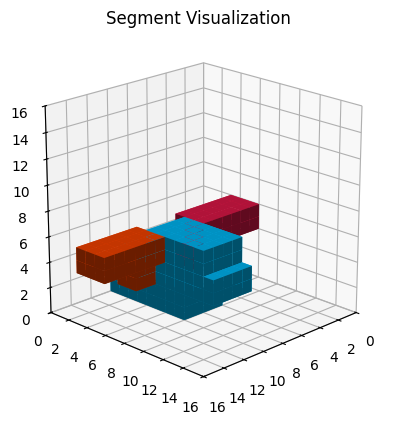

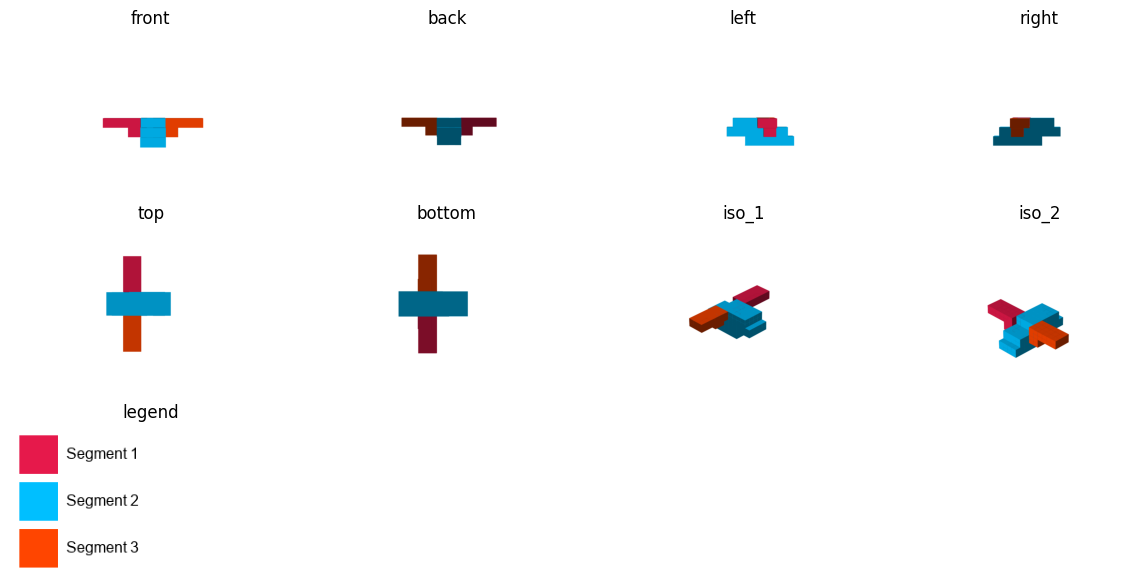

In [27]:
# file_path = "Topology Algorithm/models/toy_airplane_30k/tripo_convert_1f420a52-b8e1-4d94-a634-567465fa35c8.obj"
# file_path = "Topology Algorithm/Rodin_outputs/Bird.obj"
file_path = "base.obj"

# SEGMENT VOXELIZATION
voxel_segment = build_segmented_voxel_grid(file_path, voxel_size=16, samples_per_triangle=30)

# SEGMENT CLEANING
voxel_structure = voxel_segment.copy()

# less tiny segments
voxel_segment_clean = remap_segments_to_2x2_grid(voxel_segment, voxel_structure)

# Make disconnected segments have distinct IDs
voxel_segment_clean = split_segment_connected_components(voxel_segment_clean)

# voxel_segment_clean = voxel_segment

# Check number of segment IDs
print("RAW:", len(np.unique(voxel_segment)))
print("CLEAN:", len(np.unique(voxel_segment_clean)))

# What segments are adjacent to which?
adjacency_pairs = compute_segment_adjacency(voxel_segment_clean)
adjacency_dict = adjacency_to_dict(adjacency_pairs)

raw_contacts = compute_contact_surfaces(voxel_segment_clean)

segment_colors = generate_segment_colors(voxel_segment_clean, adjacency_dict)

# for seg, neighbors in sorted(adjacency_dict.items()):
#     print(f"Segment {seg} ({len(neighbors)} connections): {neighbors}")

visualize_segments(voxel_segment_clean, adjacency_dict, elev=20, azim=45)

views, segment_colors = generate_multiview(voxel_segment_clean, adjacency_dict)
display_multiview(views)

### Hard-code segment labels

In [ ]:
def visualize_segment_in_context(
        voxel_grid,
        target_segment,
        elev=25,
        azim=45,
        alpha_other=0.08):
    """
    Show ONE highlighted segment while keeping the
    full object visible for context.
    """

    unique_segments = np.unique(voxel_grid)
    unique_segments = [s for s in unique_segments if s > 0]

    occupied = voxel_grid > 0

    # ---------------------------------------------------------
    # COLORS
    # ---------------------------------------------------------

    facecolors = np.zeros(voxel_grid.shape + (4,))

    rng = np.random.default_rng(0)

    # Dim colors for non-target segments
    for seg in unique_segments:

        mask = voxel_grid == seg

        if seg == target_segment:

            # Bright orange highlight
            facecolors[mask] = (1.0, 0.45, 0.0, 1.0)

        else:

            color = rng.random(3)

            facecolors[mask] = (
                color[0],
                color[1],
                color[2],
                alpha_other
            )

    # ---------------------------------------------------------
    # PLOT
    # ---------------------------------------------------------

    fig = plt.figure(figsize=(12,12))
    ax = fig.add_subplot(111, projection='3d')

    ax.voxels(
        occupied,
        facecolors=facecolors,
        edgecolor='k',
        linewidth=0.15
    )

    # ---------------------------------------------------------
    # LABEL TARGET SEGMENT
    # ---------------------------------------------------------

    coords = np.argwhere(voxel_grid == target_segment)

    center = coords.mean(axis=0)

    ax.text(
        center[0],
        center[1],
        center[2],
        f"SEG {target_segment}",
        color='white',
        fontsize=16,
        ha='center'
    )

    # ---------------------------------------------------------
    # VIEW
    # ---------------------------------------------------------

    ax.view_init(elev=elev, azim=azim)

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")

    plt.title(f"Label Segment {target_segment}")

    plt.tight_layout()
    plt.show()

In [ ]:
# 1. Hard-coded labels in order

# For Bird
hardcoded_labels = [
    'left_wing', 'body', 'right_wing'
]

# For airplane_30k
# hardcoded_labels = [
#     'left_engine', 'upper_wing', 'left_wheel', 'left_tail', 'left_support', 
#     'body', 'propeller_blade', 'right_wheel', 'right_engine', 'right_tail', 
#     'right_support'
# ]

# 2. Initialize the exact dictionary structure you want

final_output_dict = {
    "object_type": "bird",
    "segments": {}
}

# For airplane_30k
# final_output_dict = {
#     "object_type": "airplane",
#     "segments": {}
# }

all_segments = sorted(np.unique(voxel_segment_clean))
all_segments = [s for s in all_segments if s > 0]

for i, seg_id in enumerate(all_segments):

    # visualize_segment_in_context(
    #     voxel_segment_clean,
    #     seg_id,
    #     elev=20,
    #     azim=45
    # )
    
    label = hardcoded_labels[i]

    # 3. Store the seg_id as a string key to match your target output
    final_output_dict["segments"][int(seg_id)] = label

# 4. Print the final result
print(final_output_dict)

In [ ]:
object_type = final_output_dict["object_type"]
print(object_type)

segment_labels_dict = final_output_dict["segments"]
print(segment_labels_dict)

## LLM Packaging

### LLM1 (Segment Labeling) 
(Commented Out Due to Hard-Coded Labels)

In [ ]:
def build_scene_state(voxel_grid, adjacency_dict, segment_colors):

    segment_ids = sorted([
        int(x)
        for x in np.unique(voxel_grid)
        if x != 0
    ])

    scene_state = {
        "num_segments": len(segment_ids),
        "segment_ids": segment_ids,
        "segments": {}
    }

    for sid in segment_ids:

        scene_state["segments"][str(sid)] = {
            "color_rgb": list(
                map(int, segment_colors[sid])
            ),
            "neighbors": [
                int(n)
                for n in adjacency_dict.get(sid, [])
            ]
        }

    return scene_state

In [ ]:
# ---- STEP 1: Build structured scene data ----
scene_state = build_scene_state(
    voxel_segment_clean,
    adjacency_dict,
    segment_colors
)
print("Building scene_state...")
print("Done.")

In [ ]:
def image_to_base64(pil_img):
    buf = io.BytesIO()
    pil_img.save(buf, format="PNG")
    return base64.b64encode(buf.getvalue()).decode("utf-8")

In [ ]:
url = "http://localhost:11434/api/chat"

# ---- STEP 1.5: Build Dynamic JSON Schema ----

segment_schema = {
    str(i): {"type": "string"}
    for i in scene_state["segment_ids"]
}

required_ids = [
    str(i) for i in scene_state["segment_ids"]
]

schema = {
    "type": "object",
    "properties": {
        "object_type": {"type": "string"},
        "segments": {
            "type": "object",
            "properties": segment_schema,
            "required": required_ids,
            "additionalProperties": False
        }
    },
    "required": ["object_type", "segments"],
    "additionalProperties": False
}

# ---- STEP 2: Prompt ----
teacher_prompt = "This is a segmented 3D object." \
"A human previously suggested it may be an bird." \
"If applicable, the object may contain symmetric appendages such as wings."

segment_id_list = ", ".join(map(str, scene_state["segment_ids"]))

prompt = f"""
You are analyzing a segmented 3D voxel object shown from multiple views.

Teacher Context:
{teacher_prompt}

IMPORTANT:
You are labeling INDIVIDUAL SEGMENTS, not the whole object.

Segment Metadata:
{json.dumps(scene_state, indent=2)}

TASK 1: OBJECT NAME
Infer the most likely real-world object type based on visible structure and Teacher Context.

Rules:
- Must be a concrete object category (e.g., “airplane”, “chair”, “robot”, “cat”, “car”, “bird”)
- Do NOT use generic phrases like:
  - "segmented object"
  - "voxel object"
  - "3D model"
- If uncertain, choose the BEST plausible category from visible structure, not “unknown”


TASK 2: SEGMENT LABELING
Assign ONE structural semantic label to EACH segment ID.

Your goal is to create the most informative and distinct segmentation labels possible.

Segment IDs:
{segment_id_list}

CORE PRINCIPLES:
- Label every segment exactly once
- Use all segment IDs
- Treat segments as separate pieces first, then infer their role in the object
- Prefer meaningful distinctions over repeating generic labels
- Neighboring segments should usually receive different labels if they appear to serve different structural roles
- Use shape, position, symmetry, and attachment relationships
- Use the images first, metadata second

LABEL STYLE:
- Labels must be SHORT noun phrases (1 to 3 words max)
- Use structural nouns, not full descriptions
- Good examples:
  core, body, side_panel, upper_fin, rear_extension, left_support, connector, tip
- Bad examples:
  front left segment of the airplane
  piece on the right side
  part near the back
- Prefer reusable compact labels
- Use underscores instead of long phrases

GOOD LABEL BEHAVIOR:
- Distinguishes mirrored or symmetric parts
- Distinguishes central body vs outer attachments
- Distinguishes support pieces vs main surfaces
- Distinguishes front/rear or upper/lower regions when visible

AVOID:
- Repeating one generic label many times unless clearly justified
- Describing colors
- Copying metadata
- Summarizing the whole object
- Guessing object identity instead of segment role

FORBIDDEN:
- Do not use the words "segment", "piece", "part", or "object" in labels
- Do not mention airplane, vehicle, machine, or guessed object type in labels
- Do not create sentence-like labels

GLOBAL OBJECTIVE:
Use the full set of segments to produce a coherent structural decomposition of the object.

HARD CONSTRAINT:
Output MUST include exactly {scene_state["num_segments"]} labeled segments.

OUTPUT REQUIREMENTS:
Return ONLY valid JSON in this format:

{{
  "object_type": "...",
  "segments": {{
    "1": "label",
    "2": "label"
  }}
}}
"""

# ---- STEP 3: Call Ollama ----
selected_views = [
    views[0], 
    # views[1], 
    views[2], 
    # views[3], 
    views[4], 
    # views[5], 
    views[6], 
    # views[7], 
    views[8]
]

payload = {
    "model": "llava:13b",  # switch to qwen2-vl (more computationally heavy model) later
    "messages": [
        {
            "role": "system",
            "content": "You are an expert 3D object understanding assistant. You strictly follow instructions."
        },
        {
            "role": "user",
            "content": prompt,
            "images": [
                image_to_base64(v["image"])
                for v in selected_views
            ]
        }
    ],
    "stream": False,
    "format": schema,
    "options": {
        "temperature": 0.2,  # more deterministic
        "num_ctx": 8192
    }
}

llm1_response = requests.post(url, json=payload)

# ---- STEP 4: Output ----
try:
    llm1_output = llm1_response.json()["message"]["content"]
    print(llm1_output)
except Exception as e:
    print("ERROR:", e)
    print(llm1_response.text)

In [ ]:
def parse_llm_segments(result_json):

    cleaned = re.sub(r"```json\s*|\s*```", "", result_json.strip())
    data = json.loads(cleaned)

    object_type = data["object_type"]

    segment_labels = {
        int(k): v for k, v in data["segments"].items()
    }

    return object_type, segment_labels

In [ ]:
object_type, segment_labels_dict = parse_llm_segments(llm1_output)

print(segment_labels_dict)

### Wheel Connection Block

In [ ]:
WHEEL_BIG_ID = 900
WHEEL_SMALL_ID = 901

In [ ]:
def detect_wheel_segments(segment_labels):
    wheel_segments = set()

    for sid, label in segment_labels.items():
        label = label.lower()

        if "wheel" in label:
            wheel_segments.add(sid)

    return wheel_segments

In [ ]:
wheel_segments = detect_wheel_segments(segment_labels_dict)

print("Wheel segments:", wheel_segments)

In [ ]:
def compute_interface_center_and_normal(contact_list):
    """
    Stable centroid + dominant normal from contact surface
    """

    points = np.array([c["pos"] for c in contact_list])
    normals = np.array([c["normal"] for c in contact_list])

    center = np.median(points, axis=0).round().astype(int)
    
    # dominant axis normal
    axis_strength = np.sum(np.abs(normals), axis=0)
    dominant_axis = np.argmax(axis_strength)

    sign = np.sign(np.sum(normals[:, dominant_axis]))
    if sign == 0:
        sign = 1

    normal = np.zeros(3, dtype=int)
    normal[dominant_axis] = int(sign)

    print("CENTER:", center, "NORMAL:", normal)

    return tuple(center), tuple(normal)

In [ ]:
def detect_valid_wheel_sites(voxel_segment, wheel_segments):
    """
    Returns valid wheel placements based on:
    - exactly 1 neighboring segment
    - contact area > 1 (prefer >4)
    """

    contacts = compute_contact_surfaces(voxel_segment)

    wheel_sites = {}

    for (a, b), contact_list in contacts.items():

        if a not in wheel_segments and b not in wheel_segments:
            continue

        wheel_sid = a if a in wheel_segments else b
        other_sid = b if wheel_sid == a else a

        area = len(contact_list)

        # collect contacts per wheel segment
        if wheel_sid not in wheel_sites:
            wheel_sites[wheel_sid] = {}

        wheel_sites[wheel_sid][other_sid] = {
            "contacts": contact_list,
            "area": area
        }

    valid_sites = []

    for wheel_sid, neighbors in wheel_sites.items():

        # Must have at least one neighbor
        if len(neighbors) == 0:
            continue

        # pick strongest contact (dominant interface)
        other_sid, info = max(neighbors.items(), key=lambda x: x[1]["area"])
        area = info["area"]

        # reject weak/noisy contacts
        if area < 2:
            continue

        valid_sites.append({
            "wheel_segment": wheel_sid,
            "neighbor_segment": other_sid,
            "contacts": info["contacts"],
            "area": area
        })

    return valid_sites

In [ ]:
def get_all_wheel_attachment_candidates(voxel_segment, wheel_segments):
    """
    Returns ALL possible wheel → segment contact pairs.
    DOES NOT choose best one.
    """

    contacts = compute_contact_surfaces(voxel_segment)

    candidates = []

    for (a, b), contact_list in contacts.items():

        if a not in wheel_segments and b not in wheel_segments:
            continue

        wheel_sid = a if a in wheel_segments else b
        other_sid = b if wheel_sid == a else a

        candidates.append({
            "wheel_segment": wheel_sid,
            "candidate_segment": other_sid,
            "contacts": contact_list,
            "area": len(contact_list)
        })

    return candidates

In [ ]:
def select_wheel_attachment_segment(candidates):
    """
    Manual selection of correct attachment segment.
    """

    print("\n=== WHEEL ATTACHMENT CANDIDATES ===\n")

    for i, c in enumerate(candidates):

        print(f"[{i}] Wheel {c['wheel_segment']} → Segment {c['candidate_segment']}")
        print(f"    contact area: {c['area']}\n")

    choice = input(
        "Select correct attachment segment index: "
    ).strip()

    try:
        idx = int(choice)
        return candidates[idx]

    except:
        print("Invalid selection")
        return None

### LLM2 (Segment-to-segment interface connection classification)

In [ ]:
def build_connection_candidates(contacts, segment_labels):

    connection_data = []

    for idx, ((s1, s2), contact_list) in enumerate(contacts.items()):

        interface_info = compute_interface_centroid(contact_list)

        # normals = np.array([c["normal"] for c in contact_list])
        # avg_normal = normals.mean(axis=0)
        # avg_normal = avg_normal / (np.linalg.norm(avg_normal) + 1e-6)

        connection_data.append({
            "connection_id": int(idx),
            "segment_a": int(s1),
            "segment_b": int(s2),

            "label_a": str(segment_labels.get(s1, "unknown")),
            "label_b": str(segment_labels.get(s2, "unknown")),

            # GEOMETRIC METADATA
            "interface_center": [
                int(v)
                for v in interface_info["center"]
            ],

            "interface_normal": [
                int(v)
                for v in interface_info["normal"]
            ],

            "contact_area": int(
                interface_info["num_contacts"]
            )
        })

    return connection_data

In [ ]:
def build_llm2_payload(
    object_type,
    connection_candidates
):

    return {
        "object_type": object_type,
        "connections": connection_candidates
    }

In [ ]:
def build_connection_prompt(payload):

    return f"""
You are classifying mechanical relationships between connected parts of a 3D object.

Object type:
{payload["object_type"]}

You are given EXACTLY {len(payload["connections"])} pairwise connections.

Each connection contains:
- connection_id
- label_a
- label_b

Connections:
{json.dumps(payload["connections"], indent=2)}

------------------------------------------------------------
TASK
------------------------------------------------------------
For each connection:

1. Assign ONE interaction type (block_type)
2. Provide a short reasoning (1 sentence max)
3. Provide a confidence score (0.0 to 1.0)

------------------------------------------------------------
ALLOWED INTERACTION TYPES
------------------------------------------------------------
- rigid
- hinge
- rotation
- wheel

------------------------------------------------------------
DEFINITIONS (IMPORTANT)
------------------------------------------------------------

rigid:
- No intended relative motion between parts
- Continuous structural connection
- No visible articulation or pivot behavior

hinge:
- One part rotates around a localized pivot or joint
- Movement is constrained to a single axis or joint region

rotation:
- Continuous spinning motion around an axis
- Typically circular or rotor-like behavior

wheel:
- Circular element intended to roll or rotate while contacting a surface

------------------------------------------------------------
CRITICAL RULES
------------------------------------------------------------

1. You MUST output EXACTLY {len(payload["connections"])} results
2. You MUST include EVERY connection_id exactly once
3. DO NOT modify connection IDs
4. DO NOT use coordinates, geometry calculations, or 3D assumptions
5. ONLY use semantic meaning from label_a and label_b

6. DO NOT treat any class (especially "rigid") as the default or most likely.
   All interaction types are equally likely before observing labels.

7. Confidence MUST reflect ONLY strength of evidence in labels,
   NOT frequency or typicality of a class.

------------------------------------------------------------
CONFIDENCE RULES (VERY IMPORTANT)
------------------------------------------------------------

Confidence measures how clearly the labels support the chosen interaction type.

It does NOT measure how common or expected the label is.

Use full range:

- 0.85 – 1.00 : very strong, unambiguous evidence
- 0.65 – 0.85 : strong evidence, minor ambiguity possible
- 0.40 – 0.65 : uncertain / mixed signals
- 0.15 – 0.40 : weak evidence, mostly guess
- 0.00 – 0.15 : almost no evidence

Important:
- DO NOT systematically assign higher confidence to rigid
- DO NOT use confidence to express preference for conservative labels
- Confidence must be symmetric across all classes

------------------------------------------------------------
HEURISTICS (SOFT ONLY, NOT RULES)
------------------------------------------------------------

- wheel ↔ body → wheel
- circular / axle-like semantic pairing → rotation
- joint-like or pivot-like semantic relation → hinge
- otherwise → rigid

These are weak priors only. Always override if labels suggest otherwise.

------------------------------------------------------------
BLOCK KIT CONSTRAINTS (IMPORTANT SYSTEM LIMIT)
------------------------------------------------------------

You are selecting interaction types under a limited hardware constraint.

Available blocks per full object:

- hinge: 2 total available
- rotation: 2 total available
- wheel: 4 total available
- rigid: unlimited (default fallback capacity)

IMPORTANT RULES:

1. You are NOT required to use all limited blocks.
   Unused specialized blocks are allowed.
   You MUST NOT use more than the available blocks.

2. You MUST NOT assign hinge, rotation, or wheel unless there is strong semantic evidence.

3. Rigid is the safe fallback ONLY when evidence is unclear.

4. Do NOT "spend" limited blocks unnecessarily.
   Treat hinge/rotation/wheel as high-precision resources.

5. Prefer this decision order:

   (a) wheel → only if clear rolling / circular contact semantics exist  
   (b) rotation → only if clear spinning / rotor-like semantics exist  
   (c) hinge → only if clear pivot / articulated joint semantics exist  
   (d) rigid → all remaining cases

6. If evidence is weak or ambiguous, ALWAYS choose rigid,
   even if limited blocks remain unused.

7. The goal is accuracy, NOT full utilization of special blocks.

------------------------------------------------------------
OUTPUT FORMAT (STRICT JSON ONLY)
------------------------------------------------------------

Return exactly:

{{
  "connections": [
    {{
      "connection_id": 0,
      "block_type": "rigid | hinge | rotation | wheel",
      "reason": "short explanation of label-based reasoning",
      "confidence": 0.0
    }}
  ]
}}
"""

In [ ]:
# # For hard_coded segment labels

# # Run this if build_connection_candidates expects integer IDs instead of string IDs
# integer_key_segments = {int(k): v for k, v in final_output_dict["segments"].items()}

# connection_candidates = build_connection_candidates(
#     raw_contacts,
#     integer_key_segments
# )

# print(connection_candidates)

In [ ]:
connection_candidates = build_connection_candidates(
    raw_contacts,
    segment_labels_dict
)

print(connection_candidates)

llm2_payload = build_llm2_payload(
    object_type,
    connection_candidates
)

connection_prompt = build_connection_prompt(llm2_payload)

num_connections = len(llm2_payload["connections"])

connection_schema = {
    "type": "object",
    "properties": {
        "connections": {
            "type": "array",
            "minItems": num_connections,
            "maxItems": num_connections,
            "items": {
                "type": "object",
                "properties": {
                    "connection_id": {"type": "integer"},
                    "block_type": {"type": "string"},
                    "reason": {"type": "string"},
                    "confidence": {
                        "type": "number",
                        "minimum": 0.0,
                        "maximum": 1.0
                    }
                },
                "required": [
                    "connection_id",
                    "block_type",
                    "reason",
                    "confidence"
                ],
                "additionalProperties": False
            }
        }
    },
    "required": ["connections"],
    "additionalProperties": False
}

In [ ]:
url = "http://localhost:11434/api/chat"

payload = {
    "model": "qwen2.5:14b",
    "messages": [
        {
            "role": "system",
            "content": "You are an expert mechanical designer."
        },
        {
            "role": "user",
            "content": connection_prompt
        }
    ],
    "stream": False,
    "format": connection_schema,
    "options": {
        "temperature": 0.2
    }
}

llm2_response = requests.post(url, json=payload)

try:
    llm2_output = llm2_response.json()["message"]["content"]
    print(llm2_output)
except Exception as e:
    print("ERROR:", e)
    print(llm2_response.text)

In [ ]:
def combined_view(llm2_output, llm2_payload):

    lookup = {
        c["connection_id"]: c
        for c in llm2_payload["connections"]
    }

    enriched = []

    for c in llm2_output["connections"]:
        base = lookup[c["connection_id"]]

        enriched.append({
            **c,
            "label_a": base["label_a"],
            "label_b": base["label_b"],
            "segment_a": base["segment_a"],
            "segment_b": base["segment_b"]
        })

    return enriched

In [ ]:
llm2_output = json.loads(llm2_output)

In [ ]:
llm_connections = combined_view(llm2_output, llm2_payload)

print(json.dumps(llm_connections, indent=2))

### Wheel Reservation Attempt 1

In [ ]:
# Reservation IDs

RESERVED_NONE = 0
RESERVED_WHEEL = 100
RESERVED_HINGE = 200
RESERVED_ROTATIONAL = 300

# -------------------------------------------------
# Reservation System
# -------------------------------------------------

class ReservationMap:

    def __init__(self, shape):

        self.shape = shape

        # voxel-level reservation mask
        self.mask = np.zeros(shape, dtype=np.int32)

        # metadata storage
        self.metadata = []

    def reserve_box(
        self,
        x, y, z,
        dx, dy, dz,
        reservation_type,
        info=None
    ):

        sx, sy, sz = self.shape

        x0 = max(0, x)
        y0 = max(0, y)
        z0 = max(0, z)

        x1 = min(sx, x + dx)
        y1 = min(sy, y + dy)
        z1 = min(sz, z + dz)

        if x1 <= x0 or y1 <= y0 or z1 <= z0:
            return False

        self.mask[
            x0:x1,
            y0:y1,
            z0:z1
        ] = reservation_type

        self.metadata.append({
            "type": reservation_type,
            "bounds": (x0, y0, z0, x1, y1, z1),
            "info": info
        })

        return True

    def is_free(self, x, y, z, dx, dy, dz):

        sx, sy, sz = self.shape

        x0 = max(0, x)
        y0 = max(0, y)
        z0 = max(0, z)

        x1 = min(sx, x + dx)
        y1 = min(sy, y + dy)
        z1 = min(sz, z + dz)

        if x1 <= x0 or y1 <= y0 or z1 <= z0:
            return False

        return np.all(
            self.mask[
                x0:x1,
                y0:y1,
                z0:z1
            ] == RESERVED_NONE
        )
    
# -------------------------------------------------
# Reserve Wheel Regions
# -------------------------------------------------

def build_tangent_frame(normal):
    n = normal / np.linalg.norm(normal)

    # pick arbitrary vector not parallel to n
    up = np.array([0, 0, 1]) if abs(n[2]) < 0.9 else np.array([0, 1, 0])

    tangent1 = np.cross(n, up)
    tangent1 /= np.linalg.norm(tangent1)

    tangent2 = np.cross(n, tangent1)

    return n, tangent1, tangent2

def extract_2x2_docking_slots(face_voxels):
    """
    Given a set of voxels on a face,
    return all valid 2x2 contiguous anchor positions.

    Each slot is defined by its 4 voxels.
    """

    vox = set(face_voxels)

    slots = []

    for x, y, z in vox:

        # try all 3 in-face directions (we don't yet know orientation, so brute test)
        candidates = [
            [(0,0,0),(1,0,0),(0,1,0),(1,1,0)],
            [(0,0,0),(1,0,0),(0,0,1),(1,0,1)],
            [(0,0,0),(0,1,0),(0,0,1),(0,1,1)],
        ]

        for pattern in candidates:

            patch = [(x+dx, y+dy, z+dz) for dx,dy,dz in pattern]

            if all(p in vox for p in patch):
                slots.append({
                    "anchor": (x, y, z),
                    "voxels": patch
                })

    return slots

def extract_face_from_contact(contact_list):
    """
    Converts contact voxels into a compact face approximation.
    """

    points = np.array([
        c["pos"] if isinstance(c, dict) else c
        for c in contact_list
    ])

    # compute dominant axis of spread
    var = np.var(points, axis=0)
    dominant_axis = np.argmax(var)

    # project into 2D face by removing dominant axis
    face = []

    for p in points:
        face.append(tuple(p))

    return face

def group_candidates_by_wheel(candidates):

    grouped = defaultdict(list)

    for c in candidates:
        grouped[c["wheel_segment"]].append(c)

    return grouped

def select_attachment_per_wheel(grouped_candidates):

    selected = []

    for wheel_id, options in grouped_candidates.items():

        print("\n" + "="*60)
        print(f"WHEEL {wheel_id} ATTACHMENT OPTIONS")
        print("="*60)

        for i, opt in enumerate(options):
            print(f"[{i}] → Segment {opt['candidate_segment']} | area={opt['area']}")

        choice = input(
            f"\nSelect segment index for wheel {wheel_id}: "
        ).strip()

        try:
            idx = int(choice)
            selected.append(options[idx])
        except:
            print("Invalid choice, skipping wheel")
            continue

    return selected

def preview_wheel_slots(
    voxel_segment,
    reservation_map,
    slots,
    wheel_sid,
    center,
    normal
):
    """
    Simulate each 2x2 docking slot visually.
    """

    previews = []

    for i, slot in enumerate(slots):

        temp_map = copy.deepcopy(reservation_map)

        anchor = slot["anchor"]

        n = np.array(normal, dtype=float)
        n = n / (np.linalg.norm(n) + 1e-8)

        # build local frame
        n, t1, t2 = build_tangent_frame(n)

        x, y, z = anchor

        for i2 in range(-2, 2):
            for j2 in range(-2, 2):
                for k2 in range(-1, 1):

                    offset = (
                        i2 * t1 +
                        j2 * t2 +
                        k2 * n
                    )

                    xi = int(round(x + offset[0]))
                    yi = int(round(y + offset[1]))
                    zi = int(round(z + offset[2]))

                    temp_map.reserve_box(
                        xi, yi, zi,
                        1, 1, 1,
                        RESERVED_WHEEL,
                        info={"wheel_segment": wheel_sid}
                    )

        previews.append(temp_map)

    return previews

def show_slot_options(voxel_segment, previews):
    """
    Display each slot candidate side-by-side.
    """

    import matplotlib.pyplot as plt

    n = len(previews)

    fig = plt.figure(figsize=(5*n, 6))

    for i, res_map in enumerate(previews):

        ax = fig.add_subplot(1, n, i+1, projection='3d')

        structure_mask = voxel_segment > 0
        wheel_mask = (res_map.mask == RESERVED_WHEEL)

        filled = structure_mask | wheel_mask

        colors = np.zeros(voxel_segment.shape + (4,), dtype=np.float32)

        # base
        colors[structure_mask] = [0.7, 0.7, 0.7, 0.08]

        # wheel overlay
        colors[wheel_mask] = [1.0, 0.2, 0.2, 1.0]

        ax.voxels(filled, facecolors=colors)

        ax.set_title(f"Slot {i}")

        ax.set_axis_off()

    plt.tight_layout()
    plt.show()


def reserve_wheel_regions(
    voxel_segment,
    reservation_map,
    valid_sites
):

    for site in valid_sites:

        wheel_sid = site["wheel_segment"]
        contacts = site["contacts"]

        # STEP 1: compute base interface
        center, normal = compute_interface_center_and_normal(site["contacts"])

        # STEP 2: extract face voxels
        face_voxels = extract_face_from_contact(site["contacts"])

        # STEP 3: generate all valid 2x2 docking slots
        slots = extract_2x2_docking_slots(face_voxels)

        if len(slots) == 0:
            print("No valid docking slots found")
            continue

        # STEP 4: pick best slot (TEMP: just choose first for now)
        center, normal = compute_interface_center_and_normal(site["contacts"])

        previews = preview_wheel_slots(
            voxel_segment,
            reservation_map,
            slots,
            wheel_sid,
            center,
            normal
        )

        show_slot_options(voxel_segment, previews)

        choice = input(
            f"Wheel {wheel_sid} → choose slot index (0-{len(slots)-1}): "
        ).strip()

        try:
            best_slot = slots[int(choice)]
        except:
            print("Invalid choice, skipping wheel")
            continue

        anchor = best_slot["anchor"]

        n = np.array(normal, dtype=float)
        n = n / (np.linalg.norm(n) + 1e-8)

        # IMPORTANT FIX: use real frame
        n, t1, t2 = build_tangent_frame(n)

        x, y, z = anchor

        print("\n[Reserve Wheel]")
        print("Wheel Segment:", wheel_sid)
        print("Center:", center)
        print("Normal:", n)
        print("T1 (axle candidate):", t1)
        print("T2:", t2)

        half_xy = 2
        half_z = 1

        success_any = False

        for i in range(-half_xy, half_xy):
            for j in range(-half_xy, half_xy):
                for k in range(-half_z, half_z):

                    offset = (
                        i * t1 +
                        j * t2 +
                        k * n
                    )

                    xi = int(round(x + offset[0]))
                    yi = int(round(y + offset[1]))
                    zi = int(round(z + offset[2]))

                    success = reservation_map.reserve_box(
                        xi, yi, zi,
                        1, 1, 1,
                        RESERVED_WHEEL,
                        info={
                            "wheel_segment": wheel_sid,
                            "normal": n.tolist(),
                            "t1": t1.tolist(),
                            "t2": t2.tolist()
                        }
                    )

                    success_any = success_any or success

        print("Reserved:", success_any)


def extract_contact_components(contact_list):
    """
    Returns ALL connected components (not just the largest)
    """

    if len(contact_list) == 0:
        return []

    def get_xyz(c):
        if isinstance(c, dict):
            if "pos" in c:
                return tuple(c["pos"])
            if "x" in c:
                return (c["x"], c["y"], c["z"])
        if isinstance(c, (tuple, list)) and len(c) == 3:
            return tuple(c)
        if hasattr(c, "__len__") and len(c) == 3:
            return (int(c[0]), int(c[1]), int(c[2]))
        raise ValueError(f"Unknown format: {c}")

    voxels = set(get_xyz(c) for c in contact_list)

    neighbors = [
        (1,0,0), (-1,0,0),
        (0,1,0), (0,-1,0),
        (0,0,1), (0,0,-1)
    ]

    visited = set()
    components = []

    for v in voxels:
        if v in visited:
            continue

        queue = [v]
        visited.add(v)
        comp = []

        while queue:
            x, y, z = queue.pop()
            comp.append((x, y, z))

            for dx, dy, dz in neighbors:
                nxt = (x+dx, y+dy, z+dz)
                if nxt in voxels and nxt not in visited:
                    visited.add(nxt)
                    queue.append(nxt)

        components.append(comp)

    return components

def compute_surface_candidates(contact_components):
    candidates = []

    for comp in contact_components:
        if len(comp) == 0:
            continue

        points = np.array(comp)

        center = np.median(points, axis=0).astype(int)

        normals = np.zeros((len(points), 3))

        # approximate normals via PCA-like axis dominance
        spread = np.var(points, axis=0)
        dominant_axis = np.argmax(spread)

        normal = np.zeros(3)
        normal[dominant_axis] = 1

        candidates.append({
            "center": tuple(center),
            "normal": tuple(normal),
            "size": len(comp),
            "voxels": comp
        })

    return candidates

# -------------------------------------------------
# Reserve Connector Regions
# -------------------------------------------------

def reserve_connector_regions(
    voxel_segment,
    reservation_map,
    llm_connections
):

    contacts = compute_contact_surfaces(voxel_segment)

    # -----------------------------------------
    # Handle wrapper dictionary
    # -----------------------------------------
    if isinstance(llm_connections, dict):

        if "connections" in llm_connections:
            connections = llm_connections["connections"]
        else:
            print("ERROR: no 'connections' key found")
            return
    else:
        connections = llm_connections

    # -----------------------------------------
    # Helper: compute segment centroid
    # -----------------------------------------
    def compute_segment_center(seg_id):
        coords = np.argwhere(voxel_segment == seg_id)
        if len(coords) == 0:
            return None
        return np.median(coords, axis=0)

    # -----------------------------------------
    # Process connections
    # -----------------------------------------
    for c in connections:

        seg_a = c.get("seg_a")
        seg_b = c.get("seg_b")

        if seg_a is None or seg_b is None:
            print("Skipping invalid connection:", c)
            continue

        conn_type = c.get("type", "rigid")

        if conn_type == "rigid":
            continue

        pair = tuple(sorted((seg_a, seg_b)))

        if pair not in contacts:
            print("Missing contact pair:", pair)
            continue

        raw_contact_list = contacts[pair]

        # keep this for surface geometry only (NOT primary driver anymore)
        components = extract_contact_components(raw_contact_list)
        candidates = compute_surface_candidates(components)
        _, surface_normal = compute_interface_center_and_normal(raw_contact_list)

        # -----------------------------------------
        # NEW: true connection direction (FIX)
        # -----------------------------------------
        center_a = compute_segment_center(seg_a)
        center_b = compute_segment_center(seg_b)

        if center_a is None or center_b is None:
            print("Missing segment centers:", seg_a, seg_b)
            continue

        vec = np.array(center_b) - np.array(center_a)
        norm = np.linalg.norm(vec)

        if norm < 1e-8:
            print("Degenerate connection direction:", seg_a, seg_b)
            continue

        connection_dir = vec / norm

        # -----------------------------------------
        # Choose reservation type
        # -----------------------------------------
        if conn_type == "hinge":
            reservation_id = RESERVED_HINGE
        elif conn_type == "rotational":
            reservation_id = RESERVED_ROTATIONAL
        else:
            continue

        x, y, z = compute_interface_center_and_normal(raw_contact_list)[0]

        print("\n[Reserve Connector]")
        print("Type:", conn_type)
        print("Segments:", seg_a, seg_b)
        print("Center:", (x, y, z))
        print("Connection dir:", connection_dir)
        print("Surface normal:", surface_normal)

        # -----------------------------------------
        # Reserve region
        # -----------------------------------------
        success = reservation_map.reserve_box(
            x,
            y,
            z,
            2,
            2,
            2,
            reservation_id,
            info={
                "segments": (seg_a, seg_b),
                "connection_direction": connection_dir.tolist(),
                "surface_normal": surface_normal,
                "type": conn_type
            }
        )

        print("Reserved:", success)

# -------------------------------------------------
# Visualize Reservations
# -------------------------------------------------

def visualize_reservations(
    voxel_segment,
    reservation_map,
    elev=25,
    azim=45
):

    fig = plt.figure(figsize=(12,10))
    ax = fig.add_subplot(111, projection='3d')

    # -------------------------------------------------
    # Masks
    # -------------------------------------------------
    structure_mask = voxel_segment > 0

    wheel_mask = (reservation_map.mask == RESERVED_WHEEL)
    hinge_mask = (reservation_map.mask == RESERVED_HINGE)
    rotational_mask = (reservation_map.mask == RESERVED_ROTATIONAL)

    reservation_mask = wheel_mask | hinge_mask | rotational_mask

    filled = structure_mask | reservation_mask

    # -------------------------------------------------
    # RGBA color volume
    # -------------------------------------------------
    colors = np.zeros(
        voxel_segment.shape + (4,),
        dtype=np.float32
    )

    # -------------------------------------------------
    # BASE STRUCTURE (VERY TRANSPARENT GRAY)
    # -------------------------------------------------
    colors[structure_mask] = [0.75, 0.75, 0.75, 0.08]

    # -------------------------------------------------
    # WHEEL (SOLID RED)
    # -------------------------------------------------
    colors[wheel_mask] = [1.0, 0.2, 0.2, 1.0]

    # -------------------------------------------------
    # HINGE (SOLID GREEN)
    # -------------------------------------------------
    colors[hinge_mask] = [0.2, 1.0, 0.2, 1.0]

    # -------------------------------------------------
    # ROTATION (SOLID BLUE)
    # -------------------------------------------------
    colors[rotational_mask] = [0.2, 0.4, 1.0, 1.0]

    # -------------------------------------------------
    # RENDER
    # -------------------------------------------------
    ax.voxels(
        filled,
        facecolors=colors,
        edgecolor='k'
    )

    ax.set_xlim(0, voxel_segment.shape[0])
    ax.set_ylim(0, voxel_segment.shape[1])
    ax.set_zlim(0, voxel_segment.shape[2])

    ax.view_init(elev=elev, azim=azim)

    ax.set_title("Voxel Reservations (Transparent Base / Solid Additions)")

    plt.show()

# -------------------------------------------------
# Normalize LLM2 connection schema
# -------------------------------------------------

def normalize_llm_connections(llm2_output):

    normalized = []

    # Handle dict wrapper
    if isinstance(llm2_output, dict):

        if "connections" in llm2_output:
            connections = llm2_output["connections"]

        elif "output" in llm2_output:
            connections = llm2_output["output"]

        else:
            connections = list(llm2_output.values())

    else:
        connections = llm2_output

    for c in connections:

        normalized.append({

            "id":
                c.get("id",
                c.get("connection_id", -1)),

            "seg_a":
                c.get("seg_a",
                c.get("segment_a")),

            "seg_b":
                c.get("seg_b",
                c.get("segment_b")),

            "type":
                c.get("type",
                c.get("block_type", "rigid")),

            "confidence":
                c.get("confidence", 1.0),

            "reason":
                c.get("reason", "")
        })

    return normalized

normalized_llm_connections = normalize_llm_connections(llm_connections)

for c in normalized_llm_connections:

    if c["seg_a"] is None or c["seg_b"] is None:
        print(c)

# -------------------------------------------------
# Build Reservation Map
# -------------------------------------------------

reservation_map = ReservationMap(
    voxel_segment_clean.shape
)

# -------------------------------------------------
# Reserve Wheel Regions
# -------------------------------------------------

# valid_sites = detect_valid_wheel_sites(
#     voxel_segment_clean,
#     wheel_segments
# )

wheel_candidates = get_all_wheel_attachment_candidates(
    voxel_segment_clean,
    wheel_segments
)

wheel_candidates = get_all_wheel_attachment_candidates(
    voxel_segment_clean,
    wheel_segments
)

grouped = group_candidates_by_wheel(wheel_candidates)

valid_sites = select_attachment_per_wheel(grouped)

reserve_wheel_regions(
    voxel_segment_clean,
    reservation_map,
    valid_sites
)

# -------------------------------------------------
# Reserve Connector Regions
# -------------------------------------------------

reserve_connector_regions(
    voxel_segment_clean,
    reservation_map,
    normalized_llm_connections
)

# -------------------------------------------------
# Visualize
# -------------------------------------------------

visualize_reservations(
    voxel_segment_clean,
    reservation_map,
    elev=-30,
    azim=-90
)


### Wheel Reservation Attempt 2

In [ ]:
voxel_segment_clean_original = voxel_segment_clean.copy()

In [ ]:
# Reservation IDs

RESERVED_NONE = 0
RESERVED_WHEEL = 100
RESERVED_HINGE = 200
RESERVED_ROTATIONAL = 300

# -------------------------------------------------
# Wheel Templates
# -------------------------------------------------

# Small wheel:
# 3x3x1
# center voxel is docking voxel

SMALL_WHEEL_TEMPLATE = [
    (x, y, 0)
    for x in range(-1, 2)
    for y in range(-1, 2)
]

SMALL_WHEEL_DOCKING = [(0, 0, 0)]


# Big wheel:
# 4x4x2
# center 2x2 face is docking interface

BIG_WHEEL_TEMPLATE = [
    (x, y, z)
    for x in range(-2, 2)
    for y in range(-2, 2)
    for z in range(-1, 1)
]

BIG_WHEEL_DOCKING = [
    (-1, -1, 0),
    (0, -1, 0),
    (-1, 0, 0),
    (0, 0, 0)
]

# -------------------------------------------------
# Reservation System
# -------------------------------------------------

class ReservationMap:

    def __init__(self, shape):

        self.shape = shape

        # voxel-level reservation mask
        self.mask = np.zeros(shape, dtype=np.int32)

        # metadata storage
        self.metadata = []

    def reserve_box(
        self,
        x, y, z,
        dx, dy, dz,
        reservation_type,
        info=None
    ):

        sx, sy, sz = self.shape

        x0 = max(0, x)
        y0 = max(0, y)
        z0 = max(0, z)

        x1 = min(sx, x + dx)
        y1 = min(sy, y + dy)
        z1 = min(sz, z + dz)

        if x1 <= x0 or y1 <= y0 or z1 <= z0:
            return False

        self.mask[
            x0:x1,
            y0:y1,
            z0:z1
        ] = reservation_type

        self.metadata.append({
            "type": reservation_type,
            "bounds": (x0, y0, z0, x1, y1, z1),
            "info": info
        })

        return True

    def is_free(self, x, y, z, dx, dy, dz):

        sx, sy, sz = self.shape

        x0 = max(0, x)
        y0 = max(0, y)
        z0 = max(0, z)

        x1 = min(sx, x + dx)
        y1 = min(sy, y + dy)
        z1 = min(sz, z + dz)

        if x1 <= x0 or y1 <= y0 or z1 <= z0:
            return False

        return np.all(
            self.mask[
                x0:x1,
                y0:y1,
                z0:z1
            ] == RESERVED_NONE
        )
    
# -------------------------------------------------
# Reserve Wheel Regions
# -------------------------------------------------

def build_tangent_frame(normal):
    n = normal / np.linalg.norm(normal)

    # pick arbitrary vector not parallel to n
    up = np.array([0, 0, 1]) if abs(n[2]) < 0.9 else np.array([0, 1, 0])

    tangent1 = np.cross(n, up)
    tangent1 /= np.linalg.norm(tangent1)

    tangent2 = np.cross(n, tangent1)

    return n, tangent1, tangent2


def transform_template(
    anchor,
    template,
    t1,
    t2,
    normal
):
    """
    Transform local wheel template voxels
    into world coordinates.
    """

    ax, ay, az = anchor

    world_voxels = []

    for dx, dy, dz in template:

        offset = (
            dx * t1 +
            dy * t2 +
            dz * normal
        )

        xi = int(round(ax + offset[0]))
        yi = int(round(ay + offset[1]))
        zi = int(round(az + offset[2]))

        world_voxels.append((xi, yi, zi))

    return world_voxels

def voxel_in_bounds(shape, v):

    x, y, z = v

    return (
        0 <= x < shape[0] and
        0 <= y < shape[1] and
        0 <= z < shape[2]
    )

def score_wheel_candidate(
    candidate_voxels,
    wheel_voxels,
    attachment_voxels,
    contact_voxels
):
    """
    Higher score is better.

    Priorities:
    1. preserve wheel voxels near interface
    2. maximize total wheel overlap
    3. avoid collisions
    """

    wheel_voxels = set(wheel_voxels)
    attachment_voxels = set(attachment_voxels)
    contact_voxels = np.array(contact_voxels)

    score = 0

    preserved = 0
    collisions = 0

    for v in candidate_voxels:

        if v in attachment_voxels:
            collisions += 1
            continue

        if v in wheel_voxels:

            preserved += 1

            # prioritize voxels near interface
            d = np.min(
                np.linalg.norm(
                    contact_voxels - np.array(v),
                    axis=1
                )
            )

            score += 10.0 / (1.0 + d)

    score += preserved * 20
    score -= collisions * 1000

    # encourage compact fit near interface
    center = np.mean(contact_voxels, axis=0)

    for v in candidate_voxels:

        d = np.linalg.norm(np.array(v) - center)

        score -= d * 0.25

    return score

def validate_wheel_candidate(
    candidate_voxels,
    voxel_segment,
    wheel_sid,
    attachment_sid
):
    """
    Valid wheel placement rules:

    1. Wheel voxels may occupy:
       - empty space
       - original wheel voxels

    2. Wheel voxels may NOT occupy:
       - attachment segment voxels
       - any other segment

    3. At least one docking voxel must overlap
       original wheel geometry.

    4. Big wheel:
       requires >=2 docking overlaps.

    5. Small wheel:
       requires >=1 docking overlap.
    """

    shape = voxel_segment.shape

    wheel_voxels = set(
        map(tuple,
            np.argwhere(voxel_segment == wheel_sid))
    )

    # -----------------------------------------
    # Bounds + collision validation
    # -----------------------------------------

    for v in candidate_voxels:

        if not voxel_in_bounds(shape, v):
            return False

        x, y, z = v

        seg = voxel_segment[x, y, z]

        # allowed:
        # empty space
        # original wheel segment

        if seg not in [0, wheel_sid]:
            return False

    # -----------------------------------------
    # Docking overlap validation
    # -----------------------------------------

    overlap = sum(
        1 for v in candidate_voxels
        if v in wheel_voxels
    )

    if len(candidate_voxels) >= 16:
        return overlap >= 2

    return overlap >= 1


def extract_2x2_docking_slots(
    face_voxels,
    normal
):
    """
    Extract valid 2x2 docking patches
    constrained to interface plane.
    """

    vox = set(face_voxels)

    normal = np.abs(normal)

    slots = []

    # -------------------------------------------------
    # Determine in-plane axes
    # -------------------------------------------------

    if normal[0] == 1:
        patterns = [[
            (0,0,0),
            (0,1,0),
            (0,0,1),
            (0,1,1)
        ]]

    elif normal[1] == 1:
        patterns = [[
            (0,0,0),
            (1,0,0),
            (0,0,1),
            (1,0,1)
        ]]

    else:
        patterns = [[
            (0,0,0),
            (1,0,0),
            (0,1,0),
            (1,1,0)
        ]]

    # -------------------------------------------------
    # Search slots
    # -------------------------------------------------

    for x, y, z in vox:

        for pattern in patterns:

            patch = [
                (x+dx, y+dy, z+dz)
                for dx,dy,dz in pattern
            ]

            if all(p in vox for p in patch):

                slots.append({
                    "anchor": (x, y, z),
                    "voxels": patch
                })

    return slots

def extract_face_from_contact(contact_list):
    """
    Converts contact voxels into a compact face approximation.
    """

    points = np.array([
        c["pos"] if isinstance(c, dict) else c
        for c in contact_list
    ])

    # compute dominant axis of spread
    var = np.var(points, axis=0)
    dominant_axis = np.argmax(var)

    # project into 2D face by removing dominant axis
    face = []

    for p in points:
        face.append(tuple(p))

    return face

def group_candidates_by_wheel(candidates):

    grouped = defaultdict(list)

    for c in candidates:
        grouped[c["wheel_segment"]].append(c)

    return grouped

def select_attachment_per_wheel(grouped_candidates):

    selected = []

    for wheel_id, options in grouped_candidates.items():

        print("\n" + "="*60)
        print(f"WHEEL {wheel_id} ATTACHMENT OPTIONS")
        print("="*60)

        for i, opt in enumerate(options):
            print(f"[{i}] → Segment {opt['candidate_segment']} | area={opt['area']}")

        choice = input(
            f"\nSelect segment index for wheel {wheel_id}: "
        ).strip()

        try:
            idx = int(choice)
            selected.append(options[idx])
        except:
            print("Invalid choice, skipping wheel")
            continue

    return selected


def preview_wheel_candidates(
    voxel_segment,
    reservation_map,
    candidates
):

    previews = []

    for c in candidates:

        temp_map = copy.deepcopy(reservation_map)

        for x, y, z in c["voxels"]:

            temp_map.reserve_box(
                x, y, z,
                1, 1, 1,
                RESERVED_WHEEL,
                info={
                    "wheel_segment": c["wheel_segment"]
                }
            )

        previews.append(temp_map)

    return previews


def show_slot_options(voxel_segment, previews):
    """
    Display each slot candidate side-by-side.
    """

    import matplotlib.pyplot as plt

    n = len(previews)

    fig = plt.figure(figsize=(5*n, 6))

    for i, res_map in enumerate(previews):

        ax = fig.add_subplot(1, n, i+1, projection='3d')

        structure_mask = voxel_segment > 0
        wheel_mask = (res_map.mask == RESERVED_WHEEL)

        filled = structure_mask | wheel_mask

        colors = np.zeros(voxel_segment.shape + (4,), dtype=np.float32)

        # base
        colors[structure_mask] = [0.7, 0.7, 0.7, 0.08]

        # wheel overlay
        colors[wheel_mask] = [1.0, 0.2, 0.2, 1.0]

        ax.voxels(filled, facecolors=colors)

        ax.set_title(f"Slot {i}")

        ax.set_axis_off()

    plt.tight_layout()
    plt.show()


def reserve_wheel_regions(
    voxel_segment,
    reservation_map,
    valid_sites
):

    for site in valid_sites:

        wheel_sid = site["wheel_segment"]
        attachment_sid = site["candidate_segment"]

        contact_list = site["contacts"]

        center, normal = compute_interface_center_and_normal(
            contact_list
        )

        n = np.array(normal, dtype=float)
        n = n / (np.linalg.norm(n) + 1e-8)

        n, t1, t2 = build_tangent_frame(n)

        wheel_voxels = set(
            map(tuple,
                np.argwhere(voxel_segment == wheel_sid))
        )

        attachment_voxels = set(
            map(tuple,
                np.argwhere(voxel_segment == attachment_sid))
        )

        face_voxels = extract_face_from_contact(contact_list)

        slots = extract_2x2_docking_slots(
            face_voxels,
            normal
        )

        print("\n--- WHEEL DEBUG ---")
        print("Wheel:", wheel_sid)
        print("Attachment:", attachment_sid)
        print("Contact voxels:", len(face_voxels))
        print("Slots found:", len(slots))
        print("Face voxels:", face_voxels[:20])

        if len(slots) == 0:
            print("No valid slots")
            continue

        # -------------------------------------------------
        # Decide wheel type
        # -------------------------------------------------

        if len(wheel_voxels) >= 16:

            template = BIG_WHEEL_TEMPLATE
            docking = BIG_WHEEL_DOCKING
            wheel_type = "big"

        else:

            template = SMALL_WHEEL_TEMPLATE
            docking = SMALL_WHEEL_DOCKING
            wheel_type = "small"

        candidate_data = []

        # -------------------------------------------------
        # Generate candidates
        # -------------------------------------------------

        for slot in slots:

            contact_anchor = np.array(
                slot["anchor"],
                dtype=float
            )

            # move wheel outward from body
            anchor = tuple(
                np.round(contact_anchor).astype(int)
            )

            candidate_voxels = transform_template(
                anchor,
                template,
                t1,
                t2,
                n
            )

            valid = validate_wheel_candidate(
                candidate_voxels,
                voxel_segment,
                wheel_sid,
                attachment_sid
            )

            if not valid:
                continue

            score = score_wheel_candidate(
                candidate_voxels,
                wheel_voxels,
                attachment_voxels,
                face_voxels
            )

            candidate_key = tuple(
                sorted(set(candidate_voxels))
            )

            already_exists = any(
                c["key"] == candidate_key
                for c in candidate_data
            )

            if already_exists:
                continue

            candidate_data.append({
                "wheel_segment": wheel_sid,
                "voxels": candidate_voxels,
                "score": score,
                "anchor": anchor,
                "type": wheel_type,
                "key": candidate_key
            })

        if len(candidate_data) == 0:
            print("No valid wheel placements")
            continue

        # -------------------------------------------------
        # Sort best-first
        # -------------------------------------------------

        candidate_data.sort(
            key=lambda x: x["score"],
            reverse=True
        )

        previews = preview_wheel_candidates(
            voxel_segment,
            reservation_map,
            candidate_data
        )

        show_slot_options(
            voxel_segment,
            previews
        )

        choice = input(
            f"Wheel {wheel_sid} choose candidate: "
        ).strip()

        try:
            chosen = candidate_data[int(choice)]

        except:
            print("Invalid choice")
            continue

        for x, y, z in chosen["voxels"]:

            reservation_map.reserve_box(
                x, y, z,
                1, 1, 1,
                RESERVED_WHEEL,
                info={
                    "wheel_segment": wheel_sid,
                    "wheel_type": chosen["type"],
                    "score": chosen["score"]
                }
            )

        print(
            f"Reserved wheel {wheel_sid} "
            f"({chosen['type']}) "
            f"score={chosen['score']:.2f}"
        )

# -------------------------------------------------
# EXTRACT WHEEL FOOTPRINT IN BLOCK SPACE
# -------------------------------------------------

def extract_wheel_attachment_primitives(reservation_map, wheel_id=RESERVED_WHEEL):
    """
    Converts wheel voxel reservations into block-level constraints.
    """

    wheel_voxels = np.argwhere(reservation_map.mask == wheel_id)

    if len(wheel_voxels) == 0:
        return []

    primitives = []

    # group by dominant face plane
    # (this is what connects it to block grid)
    xy = {}
    xz = {}
    yz = {}

    for x, y, z in wheel_voxels:
        xy[(x, y)] = xy.get((x, y), 0) + 1
        xz[(x, z)] = xz.get((x, z), 0) + 1
        yz[(y, z)] = yz.get((y, z), 0) + 1

    # pick strongest projection = attachment face
    best_plane = max([
        ("xy", xy),
        ("xz", xz),
        ("yz", yz)
    ], key=lambda p: len(p[1]))[0]

    for x, y, z in wheel_voxels:

        primitives.append({
            "pos": (x, y, z),
            "plane": best_plane
        })

    return primitives

def wheel_primitives_to_block_constraints(primitives, block_size=(2,2,2)):
    """
    Converts wheel attachment geometry into block-grid constraints.
    """

    constraints = []

    for p in primitives:

        x, y, z = p["pos"]

        # snap to 2x2 column grid
        bx = (x // 2) * 2
        by = (y // 2) * 2

        constraints.append({
            "block_cell": (bx, by),
            "z": z,
            "plane": p["plane"]
        })

    return constraints



def extract_contact_components(contact_list):
    """
    Returns ALL connected components (not just the largest)
    """

    if len(contact_list) == 0:
        return []

    def get_xyz(c):
        if isinstance(c, dict):
            if "pos" in c:
                return tuple(c["pos"])
            if "x" in c:
                return (c["x"], c["y"], c["z"])
        if isinstance(c, (tuple, list)) and len(c) == 3:
            return tuple(c)
        if hasattr(c, "__len__") and len(c) == 3:
            return (int(c[0]), int(c[1]), int(c[2]))
        raise ValueError(f"Unknown format: {c}")

    voxels = set(get_xyz(c) for c in contact_list)

    neighbors = [
        (1,0,0), (-1,0,0),
        (0,1,0), (0,-1,0),
        (0,0,1), (0,0,-1)
    ]

    visited = set()
    components = []

    for v in voxels:
        if v in visited:
            continue

        queue = [v]
        visited.add(v)
        comp = []

        while queue:
            x, y, z = queue.pop()
            comp.append((x, y, z))

            for dx, dy, dz in neighbors:
                nxt = (x+dx, y+dy, z+dz)
                if nxt in voxels and nxt not in visited:
                    visited.add(nxt)
                    queue.append(nxt)

        components.append(comp)

    return components

def compute_surface_candidates(contact_components):
    candidates = []

    for comp in contact_components:
        if len(comp) == 0:
            continue

        points = np.array(comp)

        center = np.median(points, axis=0).astype(int)

        normals = np.zeros((len(points), 3))

        # approximate normals via PCA-like axis dominance
        spread = np.var(points, axis=0)
        dominant_axis = np.argmax(spread)

        normal = np.zeros(3)
        normal[dominant_axis] = 1

        candidates.append({
            "center": tuple(center),
            "normal": tuple(normal),
            "size": len(comp),
            "voxels": comp
        })

    return candidates

# -------------------------------------------------
# Reserve Connector Regions
# -------------------------------------------------

def reserve_connector_regions(
    voxel_segment,
    reservation_map,
    llm_connections
):

    contacts = compute_contact_surfaces(voxel_segment)

    # -----------------------------------------
    # Handle wrapper dictionary
    # -----------------------------------------
    if isinstance(llm_connections, dict):

        if "connections" in llm_connections:
            connections = llm_connections["connections"]
        else:
            print("ERROR: no 'connections' key found")
            return
    else:
        connections = llm_connections

    # -----------------------------------------
    # Helper: compute segment centroid
    # -----------------------------------------
    def compute_segment_center(seg_id):
        coords = np.argwhere(voxel_segment == seg_id)
        if len(coords) == 0:
            return None
        return np.median(coords, axis=0)

    # -----------------------------------------
    # Process connections
    # -----------------------------------------
    for c in connections:

        seg_a = c.get("seg_a")
        seg_b = c.get("seg_b")

        if seg_a is None or seg_b is None:
            print("Skipping invalid connection:", c)
            continue

        conn_type = c.get("type", "rigid")

        if conn_type == "rigid":
            continue

        pair = tuple(sorted((seg_a, seg_b)))

        if pair not in contacts:
            print("Missing contact pair:", pair)
            continue

        raw_contact_list = contacts[pair]

        # keep this for surface geometry only (NOT primary driver anymore)
        components = extract_contact_components(raw_contact_list)
        candidates = compute_surface_candidates(components)
        _, surface_normal = compute_interface_center_and_normal(raw_contact_list)

        # -----------------------------------------
        # NEW: true connection direction (FIX)
        # -----------------------------------------
        center_a = compute_segment_center(seg_a)
        center_b = compute_segment_center(seg_b)

        if center_a is None or center_b is None:
            print("Missing segment centers:", seg_a, seg_b)
            continue

        vec = np.array(center_b) - np.array(center_a)
        norm = np.linalg.norm(vec)

        if norm < 1e-8:
            print("Degenerate connection direction:", seg_a, seg_b)
            continue

        connection_dir = vec / norm

        # -----------------------------------------
        # Choose reservation type
        # -----------------------------------------
        if conn_type == "hinge":
            reservation_id = RESERVED_HINGE
        elif conn_type == "rotational":
            reservation_id = RESERVED_ROTATIONAL
        else:
            continue

        x, y, z = compute_interface_center_and_normal(raw_contact_list)[0]

        print("\n[Reserve Connector]")
        print("Type:", conn_type)
        print("Segments:", seg_a, seg_b)
        print("Center:", (x, y, z))
        print("Connection dir:", connection_dir)
        print("Surface normal:", surface_normal)

        # -----------------------------------------
        # Reserve region
        # -----------------------------------------
        success = reservation_map.reserve_box(
            x,
            y,
            z,
            2,
            2,
            2,
            reservation_id,
            info={
                "segments": (seg_a, seg_b),
                "connection_direction": connection_dir.tolist(),
                "surface_normal": surface_normal,
                "type": conn_type
            }
        )

        print("Reserved:", success)

# -------------------------------------------------
# Visualize Reservations
# -------------------------------------------------

def visualize_reservations(
    voxel_segment,
    reservation_map,
    elev=25,
    azim=45
):

    fig = plt.figure(figsize=(12,10))
    ax = fig.add_subplot(111, projection='3d')

    # -------------------------------------------------
    # Masks
    # -------------------------------------------------
    structure_mask = voxel_segment > 0

    wheel_mask = (reservation_map.mask == RESERVED_WHEEL)
    hinge_mask = (reservation_map.mask == RESERVED_HINGE)
    rotational_mask = (reservation_map.mask == RESERVED_ROTATIONAL)

    reservation_mask = wheel_mask | hinge_mask | rotational_mask

    filled = structure_mask | reservation_mask

    # -------------------------------------------------
    # RGBA color volume
    # -------------------------------------------------
    colors = np.zeros(
        voxel_segment.shape + (4,),
        dtype=np.float32
    )

    # -------------------------------------------------
    # BASE STRUCTURE (VERY TRANSPARENT GRAY)
    # -------------------------------------------------
    colors[structure_mask] = [0.75, 0.75, 0.75, 0.08]

    # -------------------------------------------------
    # WHEEL (SOLID RED)
    # -------------------------------------------------
    colors[wheel_mask] = [1.0, 0.2, 0.2, 1.0]

    # -------------------------------------------------
    # HINGE (SOLID GREEN)
    # -------------------------------------------------
    colors[hinge_mask] = [0.2, 1.0, 0.2, 1.0]

    # -------------------------------------------------
    # ROTATION (SOLID BLUE)
    # -------------------------------------------------
    colors[rotational_mask] = [0.2, 0.4, 1.0, 1.0]

    # -------------------------------------------------
    # RENDER
    # -------------------------------------------------
    ax.voxels(
        filled,
        facecolors=colors,
        edgecolor='k'
    )

    ax.set_xlim(0, voxel_segment.shape[0])
    ax.set_ylim(0, voxel_segment.shape[1])
    ax.set_zlim(0, voxel_segment.shape[2])

    ax.view_init(elev=elev, azim=azim)

    ax.set_title("Voxel Reservations (Transparent Base / Solid Additions)")

    plt.show()

# -------------------------------------------------
# Normalize LLM2 connection schema
# -------------------------------------------------

def normalize_llm_connections(llm2_output):

    normalized = []

    # Handle dict wrapper
    if isinstance(llm2_output, dict):

        if "connections" in llm2_output:
            connections = llm2_output["connections"]

        elif "output" in llm2_output:
            connections = llm2_output["output"]

        else:
            connections = list(llm2_output.values())

    else:
        connections = llm2_output

    for c in connections:

        normalized.append({

            "id":
                c.get("id",
                c.get("connection_id", -1)),

            "seg_a":
                c.get("seg_a",
                c.get("segment_a")),

            "seg_b":
                c.get("seg_b",
                c.get("segment_b")),

            "type":
                c.get("type",
                c.get("block_type", "rigid")),

            "confidence":
                c.get("confidence", 1.0),

            "reason":
                c.get("reason", "")
        })

    return normalized

normalized_llm_connections = normalize_llm_connections(llm_connections)

for c in normalized_llm_connections:

    if c["seg_a"] is None or c["seg_b"] is None:
        print(c)

# -------------------------------------------------
# Build Reservation Map
# -------------------------------------------------

PAD = 2

voxel_segment_clean = np.pad(
    voxel_segment_clean_original,
    PAD
)

reservation_map = ReservationMap(
    voxel_segment_clean.shape
)

# -------------------------------------------------
# Reserve Wheel Regions
# -------------------------------------------------

# valid_sites = detect_valid_wheel_sites(
#     voxel_segment_clean,
#     wheel_segments
# )

wheel_candidates = get_all_wheel_attachment_candidates(
    voxel_segment_clean,
    wheel_segments
)

wheel_candidates = get_all_wheel_attachment_candidates(
    voxel_segment_clean,
    wheel_segments
)

grouped = group_candidates_by_wheel(wheel_candidates)

valid_sites = select_attachment_per_wheel(grouped)

reserve_wheel_regions(
    voxel_segment_clean,
    reservation_map,
    valid_sites
)

wheel_primitives = extract_wheel_attachment_primitives(reservation_map)

wheel_constraints = wheel_primitives_to_block_constraints(wheel_primitives)

# -------------------------------------------------
# Reserve Connector Regions
# -------------------------------------------------

reserve_connector_regions(
    voxel_segment_clean,
    reservation_map,
    normalized_llm_connections
)

# -------------------------------------------------
# Visualize
# -------------------------------------------------

visualize_reservations(
    voxel_segment_clean,
    reservation_map,
    elev=-30,
    azim=-90
)


#### Wheel Adjacency Visualization

In [ ]:
def visualize_reservations(
    voxel_segment,
    reservation_map,
    elev=0,
    azim=0,
    ax=None
):

    if ax is None:
        fig = plt.figure(figsize=(10, 10))
        ax = fig.add_subplot(111, projection='3d')

    # -------------------------------------------------
    # Masks
    # -------------------------------------------------
    structure_mask = voxel_segment > 0

    wheel_mask = (reservation_map.mask == RESERVED_WHEEL)
    hinge_mask = (reservation_map.mask == RESERVED_HINGE)
    rotational_mask = (reservation_map.mask == RESERVED_ROTATIONAL)

    reservation_mask = wheel_mask | hinge_mask | rotational_mask

    filled = structure_mask | reservation_mask

    # -------------------------------------------------
    # IMPORTANT FIX: use ORIGINAL segmentation input
    # -------------------------------------------------
    wheel_source_mask = np.isin(voxel_segment, wheel_segments)

    # -------------------------------------------------
    # RGBA
    # -------------------------------------------------
    colors = np.zeros(voxel_segment.shape + (4,), dtype=np.float32)

    # base object
    colors[structure_mask] = [0.75, 0.75, 0.75, 0.08]

    # ORIGINAL wheel segments (dark blue)
    colors[wheel_source_mask] = [0.0, 0.0, 0.25, 0.9]

    # reserved wheel geometry (red)
    colors[wheel_mask] = [1.0, 0.2, 0.2, 1.0]

    # hinge
    colors[hinge_mask] = [0.2, 1.0, 0.2, 1.0]

    # rotational
    colors[rotational_mask] = [0.2, 0.4, 1.0, 1.0]

    ax.voxels(
        filled,
        facecolors=colors,
        edgecolor='k'
    )

    ax.set_xlim(0, voxel_segment.shape[0])
    ax.set_ylim(0, voxel_segment.shape[1])
    ax.set_zlim(0, voxel_segment.shape[2])

    ax.view_init(elev=elev, azim=azim)

    ax.set_title("Wheel Source Voxels vs Reserved Geometry")
    
    if ax is None:
        plt.show()

def build_wheel_attachment_map_all(wheel_segments, contacts):

    wheel_to_segments = defaultdict(list)

    for (seg_a, seg_b), contact_list in contacts.items():

        a_is_wheel = seg_a in wheel_segments
        b_is_wheel = seg_b in wheel_segments

        if not a_is_wheel and not b_is_wheel:
            continue

        if a_is_wheel:
            wheel_id = seg_a
            other = seg_b
        else:
            wheel_id = seg_b
            other = seg_a

        # store ALL evidence (weighted by contact size)
        weight = len(contact_list)

        wheel_to_segments[wheel_id].append((other, weight))

    return wheel_to_segments

def generate_color_map(segment_ids):

    rng = np.random.default_rng(0)

    color_map = {}

    for sid in segment_ids:
        color_map[sid] = rng.random(3)

    return color_map

def visualize_wheel_attachment_candidates(
    voxel_segment_clean,
    wheel_to_segments,
    elev=0,
    azim=0,
    ax=None
):

    # Create axis only if one wasn't supplied
    if ax is None:
        fig = plt.figure(figsize=(10, 10))
        ax = fig.add_subplot(111, projection='3d')

    colors = np.zeros(voxel_segment_clean.shape + (3,), dtype=np.float32)

    # base structure
    colors[voxel_segment_clean > 0] = [0.75, 0.75, 0.75]

    # collect all unique segments
    all_segments = set()
    for wheel_id, candidates in wheel_to_segments.items():
        all_segments.add(wheel_id)
        for seg, _ in candidates:
            all_segments.add(seg)

    color_map = generate_color_map(all_segments)

    # wheel + all candidate attachments
    for wheel_id, candidates in wheel_to_segments.items():

        # wheel in blue (fixed for clarity)
        colors[voxel_segment_clean == wheel_id] = [0.2, 0.6, 1.0]

        for seg_id, weight in candidates:

            # blend color slightly by weight (optional visual cue)
            base_color = color_map[seg_id]

            colors[voxel_segment_clean == seg_id] = base_color

    ax.voxels(
        voxel_segment_clean > 0,
        facecolors=colors,
        edgecolor='k',
        alpha=0.45
    )

    ax.set_title("Wheel → ALL Possible Attachment Segments")

    ax.set_xlim(0, voxel_segment_clean.shape[0])
    ax.set_ylim(0, voxel_segment_clean.shape[1])
    ax.set_zlim(0, voxel_segment_clean.shape[2])

    ax.view_init(elev=elev, azim=azim)

    if ax is None:
        plt.show()

def visualize_side_by_side_views(
    voxel_segment_clean,
    reservation_map,
    wheel_to_segments,
    views
):
    """
    views: list of (elev, azim)
    """

    n = len(views)
    fig, axes = plt.subplots(
        nrows=n,
        ncols=2,
        figsize=(10, 4 * n),
        subplot_kw={'projection': '3d'}
    )

    # If only one row, normalize shape
    if n == 1:
        axes = [axes]

    for i, (elev, azim) in enumerate(views):

        ax_left = axes[i][0]
        ax_right = axes[i][1]

        # Left: candidates
        visualize_wheel_attachment_candidates(
            voxel_segment_clean,
            wheel_to_segments,
            elev=elev,
            azim=azim,
            ax=ax_left  # assumes your function can accept ax
        )
        ax_left.set_title(f"Candidates (elev={elev}, azim={azim})")

        # Right: reservations
        visualize_reservations(
            voxel_segment_clean,
            reservation_map,
            elev=elev,
            azim=azim,
            ax=ax_right  # same assumption
        )
        ax_right.set_title(f"Reservations (elev={elev}, azim={azim})")

    plt.tight_layout()
    plt.show()

contacts = compute_contact_surfaces(voxel_segment_clean)

wheel_to_segments = build_wheel_attachment_map_all(
    wheel_segments,
    contacts
)

views = [
    (0, 0),
    (0, -45),
    (-25, -90),
    (0, -135),
    (0, -180),
]

visualize_side_by_side_views(
    voxel_segment_clean,
    reservation_map,
    wheel_to_segments,
    views
)

### Start Connection Block Implementation (Attempt 05/12)

In [ ]:
def compute_interface_voxels(voxel, a, b):
    sx, sy, sz = voxel.shape
    interface = []

    dirs = [(1,0,0), (-1,0,0),
            (0,1,0), (0,-1,0),
            (0,0,1), (0,0,-1)]

    for x in range(sx):
        for y in range(sy):
            for z in range(sz):

                if voxel[x,y,z] != a:
                    continue

                for dx,dy,dz in dirs:
                    nx, ny, nz = x+dx, y+dy, z+dz

                    if not (0 <= nx < sx and 0 <= ny < sy and 0 <= nz < sz):
                        continue

                    if voxel[nx,ny,nz] == b:
                        interface.append((x,y,z))
                        break

    return interface

In [ ]:
def centroid(voxels):
    return np.mean(voxels, axis=0)

def compute_axis(centroid_a, centroid_b):
    v = centroid_a - centroid_b
    norm = np.linalg.norm(v)
    if norm == 0:
        return np.array([1,0,0])
    return v / norm

def compute_minority(voxel, a, b):
    count_a = np.sum(voxel == a)
    count_b = np.sum(voxel == b)

    return a if count_a < count_b else b

In [ ]:
def carve_cube(voxel, center, size=(2,2,2)):
    x,y,z = center
    x,y,z = int(x), int(y), int(z)

    sx, sy, sz = voxel.shape

    for i in range(size[0]):
        for j in range(size[1]):
            for k in range(size[2]):

                xi, yj, zk = x+i, y+j, z+k

                if 0 <= xi < sx and 0 <= yj < sy and 0 <= zk < sz:
                    voxel[xi,yj,zk] = 0

In [ ]:
def place_wheel(voxel, centroid_a, centroid_b):
    axis = centroid_a - centroid_b
    axis = axis / (np.linalg.norm(axis) + 1e-8)

    center = centroid_a.astype(int)

    # anchor 2x2x1
    x,y,z = center
    voxel[x:x+2, y:y+2, z:z+1] = -1  # reserved anchor

    # wheel 4x4x1 (extends outward along axis)
    direction = np.sign(axis).astype(int)

    wx, wy, wz = center + direction

    voxel[wx:wx+4, wy:wy+4, wz:wz+1] = -2  # wheel disc

In [ ]:
def build_connectors(voxel, connections):
    connectors = []

    for conn in connections:

        a, b = conn.segment_a, conn.segment_b

        interface = compute_interface_voxels(voxel, a, b)
        if len(interface) == 0:
            continue

        ca = centroid([p for p in interface])
        cb = centroid([p for p in interface])  # symmetric fallback

        minority = compute_minority(voxel, a, b)

        # carve ONLY minority
        for x,y,z in interface:
            if voxel[x,y,z] == minority:
                voxel[x,y,z] = 0

        if conn.type in ["hinge", "rotational"]:
            carve_cube(voxel, ca, (2,2,2))
            connectors.append((conn.type, ca))

        elif conn.type == "wheel":
            place_wheel(voxel, ca, cb)
            connectors.append(("wheel", ca))

    return voxel, connectors

###### end 5/12 attempt

## Block Decomposition Layer

In [28]:
BLOCK_HEIGHTS = [4, 3, 2]  # prioritize larger blocks
BLOCK_TYPE_COLORS = {
    2: np.array([0, 0, 255]),     # Blue
    3: np.array([0, 255, 0]),     # Green
    4: np.array([255, 255, 0])    # Yellow
}

CONNECTOR_COLORS = {
    "hinge": np.array([255, 105, 180]),      # pink
    "rotational": np.array([128, 0, 255]),   # purple
    "wheel": np.array([40, 40, 40])          # dark gray
}

class FaceType(Enum):
    MALE = 1
    FEMALE = 2
    NONE = 0

BLOCK_FACE_TEMPLATES = {
    (2,2,2): {
        "+X": [[FaceType.MALE]*2 for _ in range(2)],
        "-X": [[FaceType.FEMALE]*2 for _ in range(2)],
        "+Y": [[FaceType.FEMALE]*2 for _ in range(2)],
        "-Y": [[FaceType.FEMALE]*2 for _ in range(2)],
        "+Z": [[FaceType.FEMALE]*2 for _ in range(2)],
        "-Z": [[FaceType.FEMALE]*2 for _ in range(2)],
    },
    (2,2,3): {
        "+X": [[FaceType.MALE]*3 for _ in range(2)],
        "-X": [[FaceType.FEMALE]*3 for _ in range(2)],
        "+Y": [[FaceType.FEMALE]*3 for _ in range(2)],
        "-Y": [[FaceType.FEMALE]*3 for _ in range(2)],
        "+Z": [[FaceType.FEMALE]*2 for _ in range(2)],
        "-Z": [[FaceType.FEMALE]*2 for _ in range(2)],
    },
    (2,2,4): {
        "+X": [[FaceType.MALE]*4 for _ in range(2)],
        "-X": [[FaceType.FEMALE]*4 for _ in range(2)],
        "+Y": [[FaceType.FEMALE]*4 for _ in range(2)],
        "-Y": [[FaceType.FEMALE]*4 for _ in range(2)],
        "+Z": [[FaceType.FEMALE]*2 for _ in range(2)],
        "-Z": [[FaceType.FEMALE]*2 for _ in range(2)],
    },
}

CONNECTOR_FACE_TEMPLATES = {

    "hinge": {
        "+X": [[FaceType.MALE]*2 for _ in range(2)],
        "-X": [[FaceType.MALE]*2 for _ in range(2)],

        "+Y": [[FaceType.FEMALE]*2 for _ in range(2)],
        "-Y": [[FaceType.FEMALE]*2 for _ in range(2)],
        "+Z": [[FaceType.FEMALE]*2 for _ in range(2)],
        "-Z": [[FaceType.FEMALE]*2 for _ in range(2)],
    },

    "rotational": {
        "+Y": [[FaceType.MALE]*2 for _ in range(2)],
        "-Y": [[FaceType.MALE]*2 for _ in range(2)],

        "+X": [[FaceType.FEMALE]*2 for _ in range(2)],
        "-X": [[FaceType.FEMALE]*2 for _ in range(2)],
        "+Z": [[FaceType.FEMALE]*2 for _ in range(2)],
        "-Z": [[FaceType.FEMALE]*2 for _ in range(2)],
    }
}

In [29]:
class BlockInstance:
    def __init__(
            self, 
            position, 
            size, 
            base_color, 
            block_id, 
            rotation=0, 
            category="structural", 
            connector_type=None, 
            segment_a=None, 
            segment_b=None
        ):
        self.position = position
        self.size = size
        self.base_color = base_color
        self.block_id = block_id
        self.rotation = rotation
        self.category = category
        self.connector_type = connector_type
        self.segment_a = segment_a
        self.segment_b = segment_b
        self.faces = BLOCK_FACE_TEMPLATES.get(size, None)
        if self.faces is not None and rotation != 0:
            self.faces = self.rotate_faces(self.faces, rotation)

    def rotate_faces(self, faces, rotation):
        """Rotate block faces around Z axis"""
        def rotate_matrix(mat, k):
            return np.rot90(mat, -k, axes=(1,0)).tolist()
        rotated_faces = {}
        k = rotation // 90
        face_order = ["+X", "+Y", "-X", "-Y"]
        for i, face in enumerate(face_order):
            rotated_faces[face_order[(i+k)%4]] = rotate_matrix(faces[face], k)
        rotated_faces["+Z"] = faces["+Z"]
        rotated_faces["-Z"] = faces["-Z"]
        return rotated_faces

In [30]:
def voxel_to_2x2_columns(voxel_matrix):
    sx, sy, sz = voxel_matrix.shape
    columns = {}
    for x in range(0, sx-1, 2):
        for y in range(0, sy-1, 2):
            sub = voxel_matrix[x:x+2, y:y+2, :]
            occupancy = np.sum((sub > 0), axis=(0,1))
            mask = occupancy > 0
            filled = np.where(mask)[0]
            if len(filled) == 0: continue
            # split contiguous
            start = prev = filled[0]
            segments = []
            for i in filled[1:]:
                if i == prev+1:
                    prev = i
                else:
                    segments.append((start, prev))
                    start = prev = i
            segments.append((start, prev))
            for z_min, z_max in segments:
                height = z_max - z_min + 1
                if height < 2: continue
                color = int(np.bincount(sub[:,:,z_min].flatten()[sub[:,:,z_min].flatten()>0]).argmax())
                columns[(x, y, z_min)] = {"z_min": z_min, "height": height, "color": color}
    return columns

### Start Connection Block Implementation (Attempt 2, 05/13)

In [31]:
# # New 2
# def build_segment_graph(connections):
#     """
#     Converts LLM2 output into adjacency structure.
#     """
#     graph = defaultdict(list)

#     for c in connections:
#         a = c["seg_a"]
#         b = c["seg_b"]
#         t = c["type"]

#         graph[a].append({"neighbor": b, "type": t})
#         graph[b].append({"neighbor": a, "type": t})

#     return graph

# def compute_segment_priority(voxel_segment_clean, segment_labels):
#     """
#     Determines which segment is 'primary' (protected) vs secondary (carvable).
#     """

#     from collections import Counter

#     segment_sizes = Counter(segment_labels.flatten())

#     # ignore background if exists
#     if 0 in segment_sizes:
#         del segment_sizes[0]

#     # sort by volume (largest = most stable)
#     sorted_segments = sorted(segment_sizes.items(), key=lambda x: x[1], reverse=True)

#     return {
#         "primary": sorted_segments[0][0],
#         "ranking": sorted_segments
#     }

# def compute_connector_sites(voxel, segment_labels, connections):
#     """
#     Returns candidate 2x2x2 connector insertion sites.
#     """

#     sites = []

#     for c in connections:

#         seg_a = c["seg_a"]
#         seg_b = c["seg_b"]
#         conn_type = c["type"]

#         # find boundary voxels between segments
#         boundary_voxels = []

#         sx, sy, sz = voxel.shape

#         for x in range(sx - 1):
#             for y in range(sy - 1):
#                 for z in range(sz - 1):

#                     block = segment_labels[x:x+2, y:y+2, z:z+2]

#                     if np.all(block == seg_a) or np.all(block == seg_b):
#                         continue

#                     if seg_a in block and seg_b in block:
#                         boundary_voxels.append((x, y, z))

#         for v in boundary_voxels:
#             sites.append({
#                 "pos": v,
#                 "seg_a": seg_a,
#                 "seg_b": seg_b,
#                 "type": conn_type
#             })

#     return sites

# def carve_connector_space(voxel, segment_labels, sites, segment_priority):
#     """
#     Removes 2x2x2 space ONLY from non-primary segment.
#     """

#     primary = segment_priority["primary"]

#     for s in sites:

#         x, y, z = s["pos"]

#         block_seg = segment_labels[x:x+2, y:y+2, z:z+2]

#         # determine dominant segment in region
#         counts = np.bincount(block_seg.flatten())
#         dominant = np.argmax(counts)

#         # NEVER carve primary
#         if dominant == primary:
#             continue

#         # enforce clean 2x2x2 removal
#         voxel[x:x+2, y:y+2, z:z+2] = 0

#     return voxel

# def insert_connector_blocks(blocks, sites):
#     """
#     Adds 2x2x2 connector blocks after carving.
#     """

#     block_id = max(b.block_id for b in blocks) + 1

#     for s in sites:

#         x, y, z = s["pos"]
#         t = s["type"]

#         block = BlockInstance(
#             position=(x, y, z),
#             size=(2, 2, 2),
#             base_color=CONNECTOR_COLORS.get(
#                 t,
#                 np.array([200, 200, 200])  # fallback gray
#             ),
#             block_id=block_id,
#             category="connector",
#             connector_type=t
#         )

#         blocks.append(block)
#         block_id += 1

#     return blocks

# def build_connection_intent_map(connections):
#     """
#     Builds a bidirectional segment graph from LLM2 outputs.

#     Output format:
#     {
#         segment_id: [
#             (neighbor_segment_id, connection_type, confidence, connection_id),
#             ...
#         ]
#     }
#     """

#     intent = {}

#     for c in connections:

#         a = c["seg_a"]
#         b = c["seg_b"]
#         t = c["type"]
#         conf = c["confidence"]
#         cid = c["id"]

#         # initialize adjacency lists
#         if a not in intent:
#             intent[a] = []
#         if b not in intent:
#             intent[b] = []

#         # add bidirectional edge
#         intent[a].append((b, t, conf, cid))
#         intent[b].append((a, t, conf, cid))

#     return intent

# def compute_connector_sites_from_segments(
#     voxel,
#     segment_labels,
#     connections,
#     min_size=2
# ):
#     """
#     Produces safe 2x2x2 connector placements between segments.

#     Rules:
#     - Only hinge/rotational connections are processed
#     - Rigid connections are ignored
#     - Only ONE segment is carved (owner)
#     - Must preserve 2x2 column structure integrity
#     """

#     sx, sy, sz = voxel.shape
#     sites = []

#     segment_labels = np.asarray(segment_labels)

#     # ---------------------------------------------
#     # Helper: check if a 2x2x2 region is empty
#     # ---------------------------------------------
#     def region_empty(x, y, z):
#         return np.all(voxel[x:x+2, y:y+2, z:z+2] == 0)

#     # ---------------------------------------------
#     # Helper: choose carve owner segment
#     # (small heuristic: fewer voxels = owner)
#     # ---------------------------------------------
#     def choose_owner(seg_a, seg_b):
#         a_count = np.sum(segment_labels == seg_a)
#         b_count = np.sum(segment_labels == seg_b)
#         return seg_a if a_count <= b_count else seg_b

#     # ---------------------------------------------
#     # Scan each connection
#     # ---------------------------------------------
#     for c in connections:

#         seg_a = c["seg_a"]
#         seg_b = c["seg_b"]
#         ctype = c["type"]

#         # rigid = no physical connector
#         if ctype == "rigid":
#             continue

#         # -----------------------------------------
#         # Find boundary voxels between segments
#         # -----------------------------------------
#         boundary_candidates = []

#         for x in range(sx - 2):
#             for y in range(sy - 2):
#                 for z in range(sz - 2):

#                     # check 6-face adjacency between seg_a and seg_b

#                     def touches(x, y, z, dx, dy, dz):
#                         if not (0 <= x+dx < sx and 0 <= y+dy < sy and 0 <= z+dz < sz):
#                             return False

#                         return (
#                             segment_labels[x, y, z] == seg_a and
#                             segment_labels[x+dx, y+dy, z+dz] == seg_b
#                         )

#                     # check all voxel-level face adjacencies
#                     for x in range(sx):
#                         for y in range(sy):
#                             for z in range(sz):

#                                 if segment_labels[x, y, z] != seg_a:
#                                     continue

#                                 # 6-direction adjacency check
#                                 neighbors = [
#                                     (1, 0, 0),
#                                     (-1, 0, 0),
#                                     (0, 1, 0),
#                                     (0, -1, 0),
#                                     (0, 0, 1),
#                                     (0, 0, -1),
#                                 ]

#                                 for dx, dy, dz in neighbors:

#                                     nx, ny, nz = x + dx, y + dy, z + dz

#                                     if not (0 <= nx < sx and 0 <= ny < sy and 0 <= nz < sz):
#                                         continue

#                                     if segment_labels[nx, ny, nz] == seg_b:

#                                         # store midpoint as candidate anchor
#                                         bx = min(x, nx)
#                                         by = min(y, ny)
#                                         bz = min(z, nz)

#                                         boundary_candidates.append((bx, by, bz))

#         if not boundary_candidates:
#             continue

#         # -----------------------------------------
#         # Pick best candidate (closest to center bias)
#         # -----------------------------------------
#         cx, cy, cz = sx // 2, sy // 2, sz // 2

#         def score(pos):
#             x, y, z = pos
#             return abs(x - cx) + abs(y - cy) + abs(z - cz)

#         boundary_candidates.sort(key=score)

#         placed = False

#         # -----------------------------------------
#         # Try to place connector safely
#         # -----------------------------------------
#         for (x, y, z) in boundary_candidates:

#             # ensure voxel space is free (or carveable)
#             if not region_empty(x, y, z):

#                 owner = choose_owner(seg_a, seg_b)

#                 # carve ONLY from owner segment
#                 mask = (segment_labels[x:x+2, y:y+2, z:z+2] == owner)

#                 # if we would destroy BOTH segments, skip
#                 if np.any(mask) and np.any(~mask):
#                     continue

#                 # carve voxels in owner segment only
#                 segment_labels[x:x+2, y:y+2, z:z+2][mask] = 0
#                 voxel[x:x+2, y:y+2, z:z+2][mask] = 0

#             sites.append({
#                 "pos": (x, y, z),
#                 "type": ctype,
#                 "segments": (seg_a, seg_b),
#                 "connection_id": c["id"]
#             })

#             placed = True
#             break

#         # if no valid placement found, skip
#         if not placed:
#             continue

#     return sites


### Start Connection Block Implementation (Attempt 1, 05/13)

In [32]:
# # New 1
# class ConnectorPlacement:

#     def __init__(
#         self,
#         connector_type,
#         position,
#         owner_segment,
#         target_segment,
#         rotation=0
#     ):

#         self.connector_type = connector_type

#         self.position = position

#         self.owner_segment = owner_segment
#         self.target_segment = target_segment

#         self.rotation = rotation

#         # Occupancy masks
#         self.cavity_voxels = []
#         self.clearance_voxels = []

#         # Future articulation support
#         self.motion_axis = None

# def build_segment_lookup(segmented_voxels):
#     """
#     Maps:
#         voxel -> segment_id
#     """

#     lookup = {}

#     sx, sy, sz = segmented_voxels.shape

#     for x in range(sx):
#         for y in range(sy):
#             for z in range(sz):

#                 sid = segmented_voxels[x, y, z]

#                 if sid > 0:
#                     lookup[(x,y,z)] = sid

#     return lookup

# def detect_segment_interfaces(segmented_voxels):
#     """
#     Finds touching regions between segments.
#     """

#     interfaces = []

#     sx, sy, sz = segmented_voxels.shape

#     directions = [
#         (1,0,0),
#         (0,1,0),
#         (0,0,1)
#     ]

#     for x in range(sx):
#         for y in range(sy):
#             for z in range(sz):

#                 sid = segmented_voxels[x,y,z]

#                 if sid <= 0:
#                     continue

#                 for dx,dy,dz in directions:

#                     nx = x + dx
#                     ny = y + dy
#                     nz = z + dz

#                     if not (
#                         0 <= nx < sx and
#                         0 <= ny < sy and
#                         0 <= nz < sz
#                     ):
#                         continue

#                     nid = segmented_voxels[nx,ny,nz]

#                     if nid <= 0 or nid == sid:
#                         continue

#                     interfaces.append({
#                         "segment_a": sid,
#                         "segment_b": nid,
#                         "voxel_a": (x,y,z),
#                         "voxel_b": (nx,ny,nz)
#                     })

#     return interfaces

# def count_segment_connections(interfaces):

#     counts = defaultdict(int)

#     for interface in interfaces:

#         a = interface["segment_a"]
#         b = interface["segment_b"]

#         counts[a] += 1
#         counts[b] += 1

#     return counts

# def choose_cavity_owner(interface, connection_counts):
#     """
#     Minority segment rule.

#     Segment with FEWER total connections
#     receives the carve.
#     """

#     a = interface["segment_a"]
#     b = interface["segment_b"]

#     if connection_counts[a] < connection_counts[b]:
#         return a

#     if connection_counts[b] < connection_counts[a]:
#         return b

#     # Tie breaker:
#     return min(a, b)

# from scipy.ndimage import label

# def segment_voxel_matrix(voxel_matrix):
#     """
#     Labels connected voxel regions.

#     Returns:
#         segmented_voxels:
#             same shape as voxel_matrix

#             0 = empty
#             1..N = segment IDs

#         num_segments:
#             total connected components
#     """

#     structure = np.ones((3,3,3), dtype=int)

#     segmented_voxels, num_segments = label(
#         voxel_matrix > 0,
#         structure=structure
#     )

#     return segmented_voxels, num_segments

# def carve_preserves_2x2_columns(
#     voxel_matrix,
#     carve_voxels
# ):
#     """
#     Ensures carving does NOT create
#     impossible 2x2 column fragments.
#     """

#     test = voxel_matrix.copy()

#     for x,y,z in carve_voxels:
#         test[x,y,z] = 0

#     columns = voxel_to_2x2_columns(test)

#     # Reconstruct occupied voxels
#     reconstructed = np.zeros_like(test)

#     for (x,y,z), data in columns.items():

#         h = data["height"]

#         reconstructed[
#             x:x+2,
#             y:y+2,
#             z:z+h
#         ] = 1

#     # Compare occupancy
#     return np.array_equal(
#         reconstructed > 0,
#         test > 0
#     )

# def generate_2x2x2_cavity(
#     anchor_voxel
# ):
#     """
#     Creates a 2x2x2 carve region.
#     """

#     x,y,z = anchor_voxel

#     carve = []

#     for dx in range(2):
#         for dy in range(2):
#             for dz in range(2):

#                 carve.append((
#                     x + dx,
#                     y + dy,
#                     z + dz
#                 ))

#     return carve

# def generate_clearance_shell(
#     cavity_voxels,
#     padding=1
# ):
#     """
#     Generates motion clearance around connector.
#     """

#     clearance = set()

#     for x,y,z in cavity_voxels:

#         for dx in range(-padding, padding+1):
#             for dy in range(-padding, padding+1):
#                 for dz in range(-padding, padding+1):

#                     clearance.add((
#                         x+dx,
#                         y+dy,
#                         z+dz
#                     ))

#     clearance -= set(cavity_voxels)

#     return list(clearance)

# def plan_connectors(
#     segmented_voxels,
#     voxel_matrix
# ):
#     """
#     Main LLM3 connector planner.
#     """

#     interfaces = detect_segment_interfaces(
#         segmented_voxels
#     )

#     connection_counts = count_segment_connections(
#         interfaces
#     )

#     placements = []

#     for interface in interfaces:

#         owner = choose_cavity_owner(
#             interface,
#             connection_counts
#         )

#         anchor = interface["voxel_a"]

#         cavity = generate_2x2x2_cavity(anchor)

#         valid = carve_preserves_2x2_columns(
#             voxel_matrix,
#             cavity
#         )

#         if not valid:
#             continue

#         placement = ConnectorPlacement(
#             connector_type="hinge",
#             position=anchor,
#             owner_segment=owner,
#             target_segment=interface["segment_b"]
#         )

#         placement.cavity_voxels = cavity

#         placement.clearance_voxels = generate_clearance_shell(
#             cavity
#         )

#         placements.append(placement)

#     return placements

### Build Columns

In [33]:
def generate_sequences_for_height(target_height):
    results = []
    def dfs(remaining, path):
        if remaining == 0:
            results.append(path)
            return
        if remaining < 0:
            return
        for block in BLOCK_HEIGHTS:
            dfs(remaining - block, path + [block])
    dfs(target_height, [])
    return results

In [34]:
def assign_sequences_with_stagger(columns):
    """
    Assign sequences to each column such that vertical seams do NOT align
    with neighboring columns (true staggering).
    """

    # --- Helper: compute internal seams ---
    def compute_internal_seams(seq):
        seams = set()
        z = 0
        for h in seq[:-1]:  # exclude final top
            z += h
            seams.add(z)
        return seams

    # --- Precompute sequences by height ---
    max_height = max(c['height'] for c in columns.values())
    sequences_by_height = {
        h: generate_sequences_for_height(h)
        for h in range(2, max_height + 1)
    }

    assigned = {}

    # Sort columns for deterministic traversal (row-major)
    sorted_columns = sorted(columns.keys(), key=lambda k: (k[1], k[0], k[2]))

    for (x, y, z_min) in sorted_columns:
        col_data = columns[(x, y, z_min)]
        h = col_data["height"]

        candidates = sequences_by_height[h]

        best_seq = None
        best_score = -1e9

        # Only check already-assigned neighbors (left + back)
        neighbor_coords = [
            (x-2, y),
            (x, y-2),
        ]

        neighbors = []
        for nx, ny in neighbor_coords:
            if (nx, ny) in assigned:
                neighbors.append(assigned[(nx, ny)])

        for seq in candidates:
            score = 0
            candidate_seams = compute_internal_seams(seq)

            for neighbor_seq in neighbors:
                neighbor_seams = compute_internal_seams(neighbor_seq)

                # Penalize seam alignment
                overlap = candidate_seams & neighbor_seams
                score -= 20 * len(overlap)

                # Reward seam crossing (stagger)
                score += len(candidate_seams - neighbor_seams)

            # Slight preference for fewer blocks (optional, keeps larger bricks)
            score -= len(seq) * 0.1

            if score > best_score:
                best_score = score
                best_seq = seq

        assigned[(x, y)] = best_seq

    return assigned

In [35]:
def reoptimize_sequences(
    columns,
    assigned_sequences,
    max_yellow_blocks=None
):
    """
    Re-optimizes sequences while:

    1. Preserving seam staggering
    2. Strongly preferring large blocks
    3. Optionally respecting a hard cap on yellow (2x2x4) blocks

    Preference order:
        4-blocks > 3-blocks > 2-blocks
    """

    # -------------------------------------------------
    # Helper: seam positions
    # -------------------------------------------------

    def compute_internal_seams(seq):

        seams = set()

        z = 0

        for h in seq[:-1]:
            z += h
            seams.add(z)

        return seams

    # -------------------------------------------------
    # Precompute all candidate sequences
    # -------------------------------------------------

    max_height = max(c['height'] for c in columns.values())

    sequences_by_height = {
        h: generate_sequences_for_height(h)
        for h in range(2, max_height + 1)
    }

    optimized = {}

    yellow_used = 0

    # -------------------------------------------------
    # Deterministic traversal
    # -------------------------------------------------

    sorted_columns = sorted(
        assigned_sequences.keys(),
        key=lambda k: (k[1], k[0])
    )

    # -------------------------------------------------
    # Optimize each column
    # -------------------------------------------------

    for (x, y) in sorted_columns:

        original_seq = assigned_sequences[(x, y)]

        height = sum(original_seq)

        candidates = sequences_by_height[height]

        # Neighbor lookup
        neighbor_coords = [
            (x-2, y),
            (x+2, y),
            (x, y-2),
            (x, y+2)
        ]

        neighbors = [
            optimized.get(n, assigned_sequences.get(n))
            for n in neighbor_coords
            if n in assigned_sequences
        ]

        best_seq = original_seq
        best_score = -1e9

        # -------------------------------------------------
        # Evaluate all candidate sequences
        # -------------------------------------------------

        for seq in candidates:

            score = 0

            cand_seams = compute_internal_seams(seq)

            # ---------------------------------------------
            # Staggering score
            # ---------------------------------------------

            for neighbor in neighbors:

                neighbor_seams = compute_internal_seams(neighbor)

                overlap = cand_seams & neighbor_seams

                # Penalize aligned seams
                score -= 5 * len(overlap)

                # Reward staggered seams
                score += len(cand_seams - neighbor_seams)

            # ---------------------------------------------
            # Block preference scoring
            # ---------------------------------------------

            for h in seq:

                # STRONGLY prefer yellow
                if h == 4:
                    score += 8

                # Moderately prefer green
                elif h == 3:
                    score += 3

                # Discourage blue
                elif h == 2:
                    score -= 4

            # ---------------------------------------------
            # Optional yellow inventory limit
            # ---------------------------------------------

            if max_yellow_blocks is not None:

                yellow_in_seq = seq.count(4)

                projected_yellow = yellow_used + yellow_in_seq

                # HARD inventory cap
                if projected_yellow > max_yellow_blocks:

                    # Make sequence effectively invalid
                    score -= 10000

            # ---------------------------------------------
            # Fewer blocks = simpler instructions
            # ---------------------------------------------

            score -= len(seq) * 0.5

            # ---------------------------------------------
            # Keep best
            # ---------------------------------------------

            if score > best_score:
                best_score = score
                best_seq = seq

        optimized[(x, y)] = best_seq

        yellow_used += best_seq.count(4)

    # -------------------------------------------------
    # Summary
    # -------------------------------------------------

    print("\n--- INVENTORY SUMMARY ---")

    blue_count = 0
    green_count = 0
    yellow_count = 0

    for seq in optimized.values():

        blue_count += seq.count(2)
        green_count += seq.count(3)
        yellow_count += seq.count(4)

    print(f"2x2x2 (Blue):   {blue_count}")
    print(f"2x2x3 (Green):  {green_count}")

    if max_yellow_blocks is None:
        print(f"2x2x4 (Yellow): {yellow_count}\n")
    else:
        print(f"2x2x4 (Yellow): {yellow_count}/{max_yellow_blocks}\n")

    return optimized

In [36]:
def build_blocks_from_assigned_sequences(columns, assigned_sequences):
    blocks = []
    block_id = 1
    for (x, y, z), col_data in columns.items():
        seq = assigned_sequences.get((x,y))
        if seq is None: continue
        current_z = z
        for h in seq:
            block = BlockInstance(position=(x,y,current_z),
                                  size=(2,2,h),
                                  base_color=col_data['color'],
                                  block_id=block_id,
                                  rotation=0)  # rotation can be optimized later
            blocks.append(block)
            block_id += 1
            current_z += h
    return blocks

## Rotation Optimization: Constraint Satisfaction Problem (CSP)
We are treating each block as a variable, and its rotation as the decision you're solving for.

In [37]:
def build_block_grid(blocks, grid_size):
    """
    Creates a voxel occupancy grid mapping each voxel -> block_id
    """

    grid = -np.ones((grid_size, grid_size, grid_size), dtype=int)

    for block in blocks:

        x0, y0, z0 = block.position
        dx, dy, dz = block.size

        for x in range(x0, x0 + dx):
            for y in range(y0, y0 + dy):
                for z in range(z0, z0 + dz):
                    grid[x, y, z] = block.block_id

    return grid

In [38]:
def score_block_rotation(block, blocks, grid, grid_size, rotation):
    """
    Score how good a rotation is based on neighbor connections.
    """
    directions = {
        "+X": (1,0,0,"-X"),
        "-X": (-1,0,0,"+X"),
        "+Y": (0,1,0,"-Y"),
        "-Y": (0,-1,0,"+Y"),
        "+Z": (0,0,1,"-Z"),
        "-Z": (0,0,-1,"+Z"),
    }

    # Rotate faces temporarily
    faces = block.faces
    if rotation != block.rotation:
        faces = block.rotate_faces(BLOCK_FACE_TEMPLATES[block.size], rotation)

    score = 0

    x0, y0, z0 = block.position
    dx, dy, dz = block.size

    for face, (dx_off, dy_off, dz_off, opposite_face) in directions.items():

        nx = x0 + (dx_off>0)*dx + (dx_off<0)*-1
        ny = y0 + (dy_off>0)*dy + (dy_off<0)*-1
        nz = z0 + (dz_off>0)*dz + (dz_off<0)*-1

        if not (0 <= nx < grid_size and 0 <= ny < grid_size and 0 <= nz < grid_size):
            continue

        nid = grid[nx, ny, nz]
        if nid == -1 or nid == block.block_id:
            continue

        neighbor = next(b for b in blocks if b.block_id == nid)

        face_block = np.array(faces[face])
        face_neighbor = np.array(neighbor.faces[opposite_face])

        if FaceType.MALE in face_block and FaceType.FEMALE in face_neighbor:
            score += 10   # strong reward

        elif FaceType.FEMALE in face_block and FaceType.MALE in face_neighbor:
            score += 10   # strong reward

        elif FaceType.MALE in face_block and FaceType.MALE in face_neighbor:
            score -= 1000   # impossible alignment

        elif FaceType.FEMALE in face_block and FaceType.FEMALE in face_neighbor:
            score -= 100   # to encourage fully connected

    return score

In [39]:
def build_block_graph(blocks, grid, grid_size):

    graph = defaultdict(set)

    block_lookup = {
        b.block_id: b
        for b in blocks
    }

    directions = {
        "+X": (1,0,0,"-X"),
        "-X": (-1,0,0,"+X"),
        "+Y": (0,1,0,"-Y"),
        "-Y": (0,-1,0,"+Y"),
        "+Z": (0,0,1,"-Z"),
        "-Z": (0,0,-1,"+Z"),
    }

    for block in blocks:

        x0, y0, z0 = block.position
        dx, dy, dz = block.size

        for face, (dx_off, dy_off, dz_off, opposite_face) in directions.items():

            nx = x0 + (dx_off > 0) * dx + (dx_off < 0) * -1
            ny = y0 + (dy_off > 0) * dy + (dy_off < 0) * -1
            nz = z0 + (dz_off > 0) * dz + (dz_off < 0) * -1

            if not (
                0 <= nx < grid_size and
                0 <= ny < grid_size and
                0 <= nz < grid_size
            ):
                continue

            neighbor_id = grid[nx, ny, nz]

            if (
                neighbor_id == -1 or
                neighbor_id == block.block_id
            ):
                continue

            neighbor = block_lookup[neighbor_id]

            face_a = np.array(block.faces[face])[0,0]
            face_b = np.array(
                neighbor.faces[opposite_face]
            )[0,0]

            attached = (
                (face_a == FaceType.MALE and face_b == FaceType.FEMALE)
                or
                (face_a == FaceType.FEMALE and face_b == FaceType.MALE)
            )

            if attached:

                graph[block.block_id].add(neighbor_id)
                graph[neighbor_id].add(block.block_id)

    return graph

In [40]:
def compute_connected_components(blocks, grid, grid_size):
    graph = build_block_graph(blocks, grid, grid_size)

    visited = set()
    components = []

    for block in blocks:
        if block.block_id in visited:
            continue

        comp = []
        queue = deque([block.block_id])

        while queue:
            node = queue.popleft()
            if node in visited:
                continue

            visited.add(node)
            comp.append(node)

            for neigh in graph[node]:
                if neigh not in visited:
                    queue.append(neigh)

        components.append(comp)

    return components

In [41]:
def connectivity_energy(blocks, grid, grid_size):
    components = compute_connected_components(blocks, grid, grid_size)
    components = sorted(components, key=len, reverse=True)

    if len(components) <= 1:
        return 0

    main_size = len(components[0])

    energy = 0

    for comp in components[1:]:
        size = len(comp)

        # superlinear penalty (important upgrade)
        energy += (size ** 2) * 500

    # extra penalty for *number* of fragments
    energy += len(components) * 1000

    return energy

In [42]:
def score_block_rotation_csp(block, blocks, grid, grid_size, rotation):

    original_rotation = block.rotation
    original_faces = block.faces

    # apply hypothetical rotation
    block.rotation = rotation
    block.faces = block.rotate_faces(
        BLOCK_FACE_TEMPLATES[block.size],
        rotation
    )

    grid = build_block_grid(blocks, grid_size)

    # local consistency (faces)
    local_score = score_block_rotation(
        block, blocks, grid, grid_size, rotation
    )

    # global structure penalty (NEW STRONG FORM)
    global_energy = connectivity_energy(blocks, grid, grid_size)

    # restore state
    block.rotation = original_rotation
    block.faces = original_faces

    return local_score - global_energy

In [43]:
def optimize_block_rotations(blocks, grid_size, max_iters=10):
    """
    CSP-style rotation optimizer.

    Each iteration:
    1. Evaluate all blocks using the current state.
    2. Store best rotations.
    3. Apply all updates simultaneously.
    """

    for it in range(max_iters):

        grid = build_block_grid(blocks, grid_size)

        updates = {}
        changes = 0

        # -----------------------------------------
        # Evaluate best rotation for every block
        # -----------------------------------------

        for block in blocks:

            current_rotation = block.rotation

            best_rotation = current_rotation

            best_score = score_block_rotation_csp(
                block,
                blocks,
                grid,
                grid_size,
                current_rotation
            )

            for rotation in [0, 90, 180, 270]:

                if rotation == current_rotation:
                    continue

                score = score_block_rotation_csp(
                    block,
                    blocks,
                    grid,
                    grid_size,
                    rotation
                )

                if score > best_score:
                    best_score = score
                    best_rotation = rotation

            updates[block.block_id] = best_rotation

        # -----------------------------------------
        # Apply updates simultaneously
        # -----------------------------------------

        for block in blocks:

            new_rotation = updates[block.block_id]

            if new_rotation != block.rotation:

                block.rotation = new_rotation

                block.faces = block.rotate_faces(
                    BLOCK_FACE_TEMPLATES[block.size],
                    new_rotation
                )

                changes += 1

        print(
            f"Iteration {it}: "
            f"{changes} rotation changes"
        )

        if changes == 0:
            print(f"CSP converged at iteration {it}")
            break

    return blocks

### Connectivity Report Functions

In [44]:
def report_connections(blocks, grid_size):

    directions = {
        "+X": (1,0,0,"-X"),
        "-X": (-1,0,0,"+X"),
        "+Y": (0,1,0,"-Y"),
        "-Y": (0,-1,0,"+Y"),
        "+Z": (0,0,1,"-Z"),
        "-Z": (0,0,-1,"+Z"),
    }

    grid = build_block_grid(
        blocks,
        grid_size
    )

    lookup = {
        b.block_id: b
        for b in blocks
    }

    seen = set()

    print("\n===== CONNECTION REPORT =====")

    for block in blocks:

        x0, y0, z0 = block.position
        dx, dy, dz = block.size

        for face, (
            dx_off,
            dy_off,
            dz_off,
            opposite
        ) in directions.items():

            nx = x0 + (dx_off > 0)*dx + (dx_off < 0)*-1
            ny = y0 + (dy_off > 0)*dy + (dy_off < 0)*-1
            nz = z0 + (dz_off > 0)*dz + (dz_off < 0)*-1

            if not (
                0 <= nx < grid_size and
                0 <= ny < grid_size and
                0 <= nz < grid_size
            ):
                continue

            nid = grid[nx, ny, nz]

            if (
                nid == -1 or
                nid == block.block_id
            ):
                continue

            edge = tuple(
                sorted([
                    block.block_id,
                    int(nid)
                ])
            )

            if edge in seen:
                continue

            seen.add(edge)

            neighbor = lookup[nid]

            f1 = np.array(
                block.faces[face]
            )[0,0]

            f2 = np.array(
                neighbor.faces[opposite]
            )[0,0]

            valid = (
                (f1 == FaceType.MALE and f2 == FaceType.FEMALE)
                or
                (f1 == FaceType.FEMALE and f2 == FaceType.MALE)
            )

            print(
                edge,
                f"{f1.name} <-> {f2.name}",
                "VALID" if valid else "INVALID"
            )



In [45]:
def report_attachment_connectivity(blocks, grid_size):

    grid = build_block_grid(blocks, grid_size)

    components = compute_connected_components(
        blocks,
        grid,
        grid_size
    )

    components = sorted(
        components,
        key=len,
        reverse=True
    )

    print("\n===== ATTACHMENT CONNECTIVITY =====")
    print(f"Components: {len(components)}")

    for i, comp in enumerate(components):

        print(
            f"Component {i+1}: "
            f"{len(comp)} blocks"
        )

        print(
            sorted(comp)
        )

    return components



In [46]:
def report_attachment_degrees(blocks, grid_size):

    grid = build_block_grid(blocks, grid_size)

    graph = build_block_graph(
        blocks,
        grid,
        grid_size
    )

    print("\n===== ATTACHMENT DEGREES =====")

    for block_id in sorted(graph):

        print(
            f"Block {block_id}: "
            f"{len(graph[block_id])} attachments"
        )



In [47]:
def report_bridge_blocks(blocks, grid_size):

    grid = build_block_grid(
        blocks,
        grid_size
    )

    graph = build_block_graph(
        blocks,
        grid,
        grid_size
    )

    baseline = len(
        compute_connected_components(
            blocks,
            grid,
            grid_size
        )
    )

    print("\n===== BRIDGE BLOCKS =====")

    for block in blocks:

        reduced = [
            b
            for b in blocks
            if b.block_id != block.block_id
        ]

        reduced_grid = build_block_grid(
            reduced,
            grid_size
        )

        comps = compute_connected_components(
            reduced,
            reduced_grid,
            grid_size
        )

        if len(comps) > baseline:

            print(
                f"Block {block.block_id} "
                f"is a bridge"
            )


## Neighbor Mapping

In [48]:
def build_neighbor_map(blocks, grid_size):
    """
    Creates a robust connection map for assembly instructions.
    
    Each block records:
      - 'support': blocks directly beneath it (Z- direction)
      - 'side': blocks adjacent in X/Y directions (optional for stability)
    
    This version ignores strict male/female matching to ensure no missing connections.
    """
    # Create a 3D lookup grid of block IDs
    grid = np.full((grid_size, grid_size, grid_size), fill_value=-1)
    for block in blocks:
        x, y, z = block.position
        dx, dy, dz = block.size
        grid[x:x+dx, y:y+dy, z:z+dz] = block.block_id

    connection_map = {}

    for block in blocks:
        support_neighbors = set()
        side_neighbors = set()
        x0, y0, z0 = block.position
        dx, dy, dz = block.size

        # Check all 6 directions for adjacent blocks
        directions = {
            "+X": (1,0,0), "-X": (-1,0,0),
            "+Y": (0,1,0), "-Y": (0,-1,0),
            "+Z": (0,0,1), "-Z": (0,0,-1)
        }

        for face, (dx_off, dy_off, dz_off) in directions.items():
            # Determine search region
            nx_start = max(0, x0 + (dx_off>0)*dx + (dx_off<0)*-1)
            ny_start = max(0, y0 + (dy_off>0)*dy + (dy_off<0)*-1)
            nz_start = max(0, z0 + (dz_off>0)*dz + (dz_off<0)*-1)

            nx_end = min(grid_size, nx_start + dx)
            ny_end = min(grid_size, ny_start + dy)
            nz_end = min(grid_size, nz_start + dz)

            region = grid[nx_start:nx_end, ny_start:ny_end, nz_start:nz_end]
            for nid in set(region.flatten()):
                if nid == -1 or nid == block.block_id:
                    continue
                # Assign vertical support vs side adjacency
                if dz_off == -1:  # block below
                    support_neighbors.add(nid)
                elif dz_off == 0:  # side neighbors
                    side_neighbors.add(nid)

        connection_map[block.block_id] = {
            "support": list(support_neighbors),
            "side": list(side_neighbors)
        }

    return connection_map

## Visualization

In [49]:
def get_block_color(block):
    """
    Returns RGB color for a block.
    """
    # CONNECTOR BLOCKS
    if getattr(block, "category", None) == "connector":

        return CONNECTOR_COLORS.get(
            block.connector_type,
            np.array([255, 255, 255])
        )

    # NORMAL STRUCTURAL BLOCKS
    if isinstance(block.base_color, np.ndarray):
        return block.base_color

    if isinstance(
        block.base_color,
        (int, float, np.integer, np.floating)
    ):

        if block.base_color == 99:
            return np.array([180,180,180])

        return BLOCK_TYPE_COLORS.get(
            block.size[2],
            np.array([200,200,200])
        )

    return np.array([200,200,200])

In [50]:
def visualize_blocks_by_type(blocks, grid_size, elev=30, azim=45):

    voxel = np.zeros((grid_size, grid_size, grid_size), dtype=int)
    colors = np.zeros((grid_size, grid_size, grid_size, 3))

    for block in blocks:
        x, y, z = block.position
        dx, dy, dz = block.size

        color_rgb = get_block_color(block) / 255

        voxel[x:x+dx, y:y+dy, z:z+dz] = 1
        colors[x:x+dx, y:y+dy, z:z+dz] = color_rgb

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    ax.voxels(voxel > 0, facecolors=colors, edgecolor='k')

    ax.set_xlim(0, grid_size)
    ax.set_ylim(0, grid_size)
    ax.set_zlim(0, grid_size)

    ax.set_box_aspect([1,1,1])

    ax.view_init(elev=elev, azim=azim)

    plt.show()

In [51]:
def visualize_blocks_with_faces(
    blocks,
    neighbor_map,
    grid_size,
    elev=25,
    azim=45
):
    """
    Visualizes 3D blocks with face indicators and connections.
    
    - Supports the new neighbor_map format with 'support' and 'side'.
    - Colors support connections in green, side connections in gray.
    - Draws male/female face indicators (red/blue).
    """
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    # Draw blocks
    for block in blocks:
        x, y, z = block.position
        dx, dy, dz = block.size

        # Color by BLOCK TYPE (height)
        base_color = get_block_color(block) / 255.0
        muted_color = 0.6 * base_color + 0.4  # blend toward white

        ax.bar3d(
            x, y, z,
            dx, dy, dz,
            color=muted_color,
            edgecolor='k',
            alpha=0.2
        )

        # Draw male/female face indicators
        if hasattr(block, "faces"):
            for face_dir, face_grid in block.faces.items():

                if any(FaceType.MALE in row for row in face_grid):
                    face_color = (1, 0, 0)      # red
                elif any(FaceType.FEMALE in row for row in face_grid):
                    face_color = (0, 0.5, 1)    # blue
                else:
                    continue

                # Face center
                if face_dir == '+X':
                    fx, fy, fz = x + dx, y + dy/2, z + dz/2
                elif face_dir == '-X':
                    fx, fy, fz = x, y + dy/2, z + dz/2
                elif face_dir == '+Y':
                    fx, fy, fz = x + dx/2, y + dy, z + dz/2
                elif face_dir == '-Y':
                    fx, fy, fz = x + dx/2, y, z + dz/2
                elif face_dir == '+Z':
                    fx, fy, fz = x + dx/2, y + dy/2, z + dz
                elif face_dir == '-Z':
                    fx, fy, fz = x + dx/2, y + dy/2, z

                ax.scatter(fx, fy, fz, color=face_color, s=40)

    # Draw connections
    for block in blocks:
        bid = block.block_id
        x0, y0, z0 = block.position
        dx, dy, dz = block.size
        cx0, cy0, cz0 = x0 + dx/2, y0 + dy/2, z0 + dz/2

        neighbors_info = neighbor_map.get(bid, {})
        support_ids = neighbors_info.get("support", [])
        side_ids = neighbors_info.get("side", [])

        # Draw support connections in green
        for nid in support_ids:
            neighbor_block = next(b for b in blocks if b.block_id == nid)
            x1, y1, z1 = neighbor_block.position
            dx1, dy1, dz1 = neighbor_block.size
            cx1, cy1, cz1 = x1 + dx1/2, y1 + dy1/2, z1 + dz1/2

            ax.plot(
                [cx0, cx1],
                [cy0, cy1],
                [cz0, cz1],
                color='green',
                linewidth=1.0
            )

        # Draw side connections in gray
        for nid in side_ids:
            neighbor_block = next(b for b in blocks if b.block_id == nid)
            x1, y1, z1 = neighbor_block.position
            dx1, dy1, dz1 = neighbor_block.size
            cx1, cy1, cz1 = x1 + dx1/2, y1 + dy1/2, z1 + dz1/2

            ax.plot(
                [cx0, cx1],
                [cy0, cy1],
                [cz0, cz1],
                color='gray',
                linewidth=0.5,
                linestyle='--'
            )

    # Axes + camera control
    ax.set_xlim(0, grid_size)
    ax.set_ylim(0, grid_size)
    ax.set_zlim(0, grid_size)

    ax.set_box_aspect((1,1,1))

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')

    ax.view_init(elev=elev, azim=azim)

    plt.show()

##### Previous Connection Blocks Functions and Output Cells

In [52]:
# # NEW 3: SPECIAL PLACEMENT FUNCTIONS

# def snap_to_2x2_grid(x, y):
#     return (x // 2) * 2, (y // 2) * 2

# def place_wheels(voxel, segment_labels, segment_labels_text):
#     """
#     Carves space + returns wheel placements.
#     """

#     wheel_sites = []

#     for sid, label in segment_labels_text.items():

#         if "wheel" not in label.lower():
#             continue

#         coords = np.argwhere(segment_labels == sid)

#         if len(coords) == 0:
#             continue

#         center = np.round(coords.mean(axis=0)).astype(int)

#         # Try BIG wheel (4x4x2)
#         placed = False

#         for size, name in [((4,4,2), "big"), ((3,3,1), "small")]:

#             dx, dy, dz = size
#             x, y, z = center

#             x0 = x - dx//2
#             y0 = y - dy//2
#             z0 = z - dz//2

#             if (
#                 x0 < 0 or y0 < 0 or z0 < 0 or
#                 x0+dx > voxel.shape[0] or
#                 y0+dy > voxel.shape[1] or
#                 z0+dz > voxel.shape[2]
#             ):
#                 continue

#             region = voxel[x0:x0+dx, y0:y0+dy, z0:z0+dz]

#             # allow carving ONLY this segment
#             mask = (segment_labels[x0:x0+dx, y0:y0+dy, z0:z0+dz] == sid)

#             if np.all((region == 0) | mask):

#                 voxel[x0:x0+dx, y0:y0+dy, z0:z0+dz][mask] = 0

#                 wheel_sites.append({
#                     "pos": (x0, y0, z0),
#                     "size": size,
#                     "segment": sid,
#                     "type": "wheel"
#                 })

#                 placed = True
#                 break

#         if not placed:
#             print(f"[Wheel Failed] Segment {sid}")

#     return voxel, wheel_sites

# def compute_connector_sites_from_contacts(contacts, connections, voxel, segment_labels):

#     sites = []

#     for c in connections:

#         if c["type"] == "rigid":
#             continue

#         key = (min(c["seg_a"], c["seg_b"]), max(c["seg_a"], c["seg_b"]))

#         if key not in contacts:
#             continue

#         interface = compute_interface_centroid(contacts[key])

#         if interface is None:
#             continue

#         x, y, z = interface["center"]

#         # shift slightly into smaller segment
#         normal = np.array(interface["normal"])

#         x, y, z = np.array([x,y,z]) - normal

#         x, y = snap_to_2x2_grid(x, y)
#         z = int(z)

#         # bounds check
#         if x < 0 or y < 0 or z < 0 or x+2 >= voxel.shape[0] or y+2 >= voxel.shape[1] or z+2 >= voxel.shape[2]:
#             continue

#         region = voxel[x:x+2, y:y+2, z:z+2]

#         seg_a = c["seg_a"]
#         seg_b = c["seg_b"]

#         mask_a = (segment_labels[x:x+2, y:y+2, z:z+2] == seg_a)
#         mask_b = (segment_labels[x:x+2, y:y+2, z:z+2] == seg_b)

#         # carve only one side (minority)
#         if np.sum(mask_a) < np.sum(mask_b):
#             carve_mask = mask_a
#         else:
#             carve_mask = mask_b

#         RESERVED = -1
#         voxel[x:x+2, y:y+2, z:z+2][carve_mask] = RESERVED

#         sites.append({
#             "pos": (x,y,z),
#             "type": c["type"],
#             "segments": (seg_a, seg_b),
#             "connection_id": c["id"]
#         })

#     return voxel, sites

# def insert_special_blocks(blocks, connector_sites, wheel_sites):

#     block_id = max(b.block_id for b in blocks) + 1

#     # CONNECTORS
#     for s in connector_sites:

#         block = BlockInstance(
#             position=s["pos"],
#             size=(2,2,2),
#             base_color=CONNECTOR_COLORS[s["type"]],
#             block_id=block_id,
#             category="connector",
#             connector_type=s["type"],
#             segment_a=s["segments"][0],
#             segment_b=s["segments"][1]
#         )

#         block.faces = CONNECTOR_FACE_TEMPLATES.get(s["type"])

#         blocks.append(block)
#         block_id += 1

#     # WHEELS
#     for w in wheel_sites:

#         block = BlockInstance(
#             position=w["pos"],
#             size=w["size"],
#             base_color=CONNECTOR_COLORS["wheel"],
#             block_id=block_id,
#             category="wheel",
#             connector_type="wheel",
#             segment_a=w["segment"]
#         )

#         blocks.append(block)
#         block_id += 1

#     return blocks

# def build_wheel_reservations(valid_sites):
#     reservations = []

#     for site in valid_sites:

#         center, normal = compute_interface_center_and_normal(site["contacts"])

#         # Decide size
#         if site["area"] >= 6:
#             size = (4,4,2)
#             rtype = "wheel_big"
#         else:
#             size = (3,3,1)
#             rtype = "wheel_small"

#         reservations.append({
#             "type": rtype,
#             "center": center,
#             "normal": normal,
#             "size": size,
#             "segments": (site["wheel_segment"], site["neighbor_segment"])
#         })

#     return reservations

# def build_connector_reservations(voxel, segment_labels, connections):

#     reservations = []

#     sites = compute_connector_sites_from_segments(
#         voxel,
#         segment_labels,
#         connections
#     )

#     for s in sites:

#         reservations.append({
#             "type": s["type"],  # hinge / rotational
#             "position": s["pos"],
#             "size": (2,2,2),
#             "segments": s["segments"],
#             "connection_id": s["connection_id"]
#         })

#     return reservations

# def compute_reservation_bounds(res):
#     if "position" in res:
#         # already aligned (connectors)
#         x,y,z = res["position"]
#         dx,dy,dz = res["size"]
#         return (x,y,z,dx,dy,dz)

#     # wheels (center-based)
#     cx, cy, cz = res["center"]
#     dx, dy, dz = res["size"]

#     x0 = cx - dx//2
#     y0 = cy - dy//2
#     z0 = cz

#     return (x0, y0, z0, dx, dy, dz)

# def apply_reservations(voxel, segment_labels, reservations):

#     voxel = voxel.copy()
#     segment_labels = segment_labels.copy()

#     applied = []
#     failed = []

#     for res in reservations:

#         x,y,z,dx,dy,dz = compute_reservation_bounds(res)

#         # bounds check
#         if (
#             x < 0 or y < 0 or z < 0 or
#             x+dx > voxel.shape[0] or
#             y+dy > voxel.shape[1] or
#             z+dz > voxel.shape[2]
#         ):
#             failed.append(res)
#             continue

#         region = voxel[x:x+dx, y:y+dy, z:z+dz]

#         # -----------------------------------
#         # Collision rule
#         # -----------------------------------

#         # allow carving ONLY one segment
#         segs = segment_labels[x:x+dx, y:y+dy, z:z+dz]
#         unique = set(segs.flatten()) - {0}

#         if len(unique) > 1:
#             failed.append(res)
#             continue

#         # -----------------------------------
#         # Apply carve
#         # -----------------------------------

#         voxel[x:x+dx, y:y+dy, z:z+dz] = 0
#         segment_labels[x:x+dx, y:y+dy, z:z+dz] = 0

#         res["bounds"] = (x,y,z,dx,dy,dz)
#         applied.append(res)

#     return voxel, segment_labels, applied, failed

# def reservations_to_blocks(reservations, start_id=5000):

#     blocks = []
#     bid = start_id

#     for res in reservations:

#         x,y,z,dx,dy,dz = res["bounds"]

#         block = BlockInstance(
#             position=(x,y,z),
#             size=(dx,dy,dz),
#             base_color=CONNECTOR_COLORS.get(
#                 res["type"],
#                 np.array([200,200,200])
#             ),
#             block_id=bid,
#             category="connector",
#             connector_type=res["type"],
#             segment_a=res.get("segments", (None,None))[0],
#             segment_b=res.get("segments", (None,None))[1]
#         )

#         blocks.append(block)
#         bid += 1

#     return blocks


In [53]:
# # ---------------------------------
# # 1. Build reservations
# # ---------------------------------
# segment_labels = np.array(voxel_segment_clean)

# wheel_res = build_wheel_reservations(valid_sites)

# def normalize_connections(llm_connections):

#     normalized = []

#     for c in llm_connections:

#         block_type = c["block_type"].lower()

#         # normalize naming
#         if block_type == "rotation":
#             block_type = "rotational"

#         normalized.append({
#             "seg_a": c["segment_a"],
#             "seg_b": c["segment_b"],
#             "type": block_type,
#             "confidence": c.get("confidence", 1.0),
#             "id": c["connection_id"]
#         })

#     return normalized

# connections = normalize_connections(llm_connections)

# connector_res = build_connector_reservations(
#     voxel_segment_clean,
#     segment_labels,
#     connections
# )

# all_res = wheel_res + connector_res

# # ---------------------------------
# # 2. Apply reservations
# # ---------------------------------

# voxel_clean, segment_labels_clean, applied_res, failed_res = apply_reservations(
#     voxel_segment_clean,
#     segment_labels_dict,
#     all_res
# )

# print("Applied:", len(applied_res), "Failed:", len(failed_res))

# # ---------------------------------
# # 3. Convert reservations to blocks
# # ---------------------------------

# connector_blocks = reservations_to_blocks(applied_res)

# # ---------------------------------
# # 4. Build structural blocks
# # ---------------------------------

# voxel_matrix = (voxel_clean > 0).astype(int)

# columns = voxel_to_2x2_columns(voxel_matrix)
# assigned_sequences = assign_sequences_with_stagger(columns)
# optimized_sequences = reoptimize_sequences(columns, assigned_sequences)

# blocks = build_blocks_from_assigned_sequences(columns, optimized_sequences)

# # ---------------------------------
# # 5. Merge
# # ---------------------------------

# blocks.extend(connector_blocks)

In [54]:
# voxel_matrix = (voxel_segment_clean > 0).astype(int)

# segment_labels = np.array(voxel_segment_clean)

# connections = []
# for item in llm_connections:
#     if item["block_type"] == "rigid":
#         continue
#     connections.append({
#         "seg_a": item["segment_a"],
#         "seg_b": item["segment_b"],
#         "type": item["block_type"],
#         "confidence": item["confidence"],
#         "labels": (item["label_a"], item["label_b"]),
#         "id": item["connection_id"]
#     })
# print("Connections parsed:", len(connections))

# # =========================
# # STEP 1: PLACE WHEELS
# # =========================
# voxel_matrix, wheel_sites = place_wheels(
#     voxel_matrix,
#     segment_labels,
#     segment_labels_dict   # <-- your LLM1 labels dict
# )

# # =========================
# # STEP 2: PLACE CONNECTORS
# # =========================
# voxel_matrix, connector_sites = compute_connector_sites_from_contacts(
#     raw_contacts,
#     connections,
#     voxel_matrix,
#     segment_labels
# )

# print("Wheel sites:", len(wheel_sites))
# print("Connector sites:", len(connector_sites))


# columns = voxel_to_2x2_columns(voxel_matrix)

# assigned_sequences = assign_sequences_with_stagger(columns)
# optimized_sequences = reoptimize_sequences(columns, assigned_sequences)

# blocks = build_blocks_from_assigned_sequences(columns, optimized_sequences)

# # connection_intent = build_connection_intent_map(connections)

# # connector_sites = compute_connector_sites_from_segments(
# #     voxel_matrix,
# #     segment_labels,
# #     connections,
# #     connection_intent
# # )
# # print(f"Generated {len(connector_sites)} connector sites")

# blocks = insert_special_blocks(
#     blocks,
#     connector_sites,
#     wheel_sites
# )

# grid_size = voxel_matrix.shape[0]

# blocks = optimize_block_rotations(blocks, grid_size)

# neighbor_map = build_neighbor_map(blocks, grid_size)

# # Visualizations

# visualize_blocks_by_type(blocks, grid_size)

# visualize_blocks_with_faces(blocks, neighbor_map, grid_size)

In [55]:
# print("Unique segment labels:", np.unique(segment_labels))
# print("Voxel matrix sum:", np.sum(voxel_matrix))
# print("Segment A/B sample:", connections[0]["seg_a"], connections[0]["seg_b"])

# # check if any adjacency exists at all
# found = 0

# for x in range(segment_labels.shape[0]-1):
#     for y in range(segment_labels.shape[1]):
#         for z in range(segment_labels.shape[2]):
#             if segment_labels[x,y,z] != segment_labels[x+1,y,z]:
#                 found += 1

# print("X-face adjacencies:", found)

### Pipeline Output Cell


--- INVENTORY SUMMARY ---
2x2x2 (Blue):   12
2x2x3 (Green):  4
2x2x4 (Yellow): 12

Iteration 0: 20 rotation changes
Iteration 1: 19 rotation changes
Iteration 2: 19 rotation changes
Iteration 3: 14 rotation changes
Iteration 4: 8 rotation changes
Iteration 5: 0 rotation changes
CSP converged at iteration 5

================ CONNECTIVITY REPORT ================


===== CONNECTION REPORT =====
(1, 3) MALE <-> FEMALE VALID
(1, 2) FEMALE <-> MALE VALID
(2, 4) FEMALE <-> FEMALE INVALID
(3, 5) MALE <-> FEMALE VALID
(3, 4) FEMALE <-> MALE VALID
(4, 6) FEMALE <-> FEMALE INVALID
(5, 8) MALE <-> FEMALE VALID
(5, 6) FEMALE <-> MALE VALID
(6, 9) FEMALE <-> FEMALE INVALID
(7, 15) FEMALE <-> FEMALE INVALID
(7, 8) MALE <-> FEMALE VALID
(8, 16) FEMALE <-> FEMALE INVALID
(8, 9) MALE <-> FEMALE VALID
(9, 17) FEMALE <-> MALE VALID
(9, 11) MALE <-> FEMALE VALID
(9, 10) FEMALE <-> FEMALE INVALID
(10, 18) FEMALE <-> MALE VALID
(6, 10) FEMALE <-> FEMALE INVALID
(10, 12) MALE <-> FEMALE VALID
(11, 19) MALE <

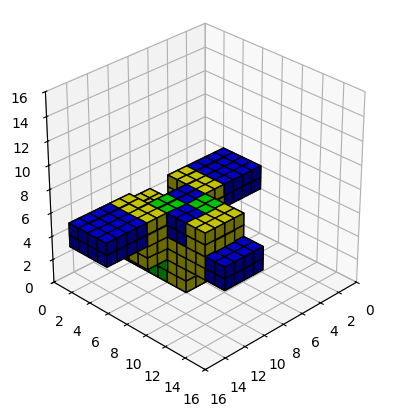

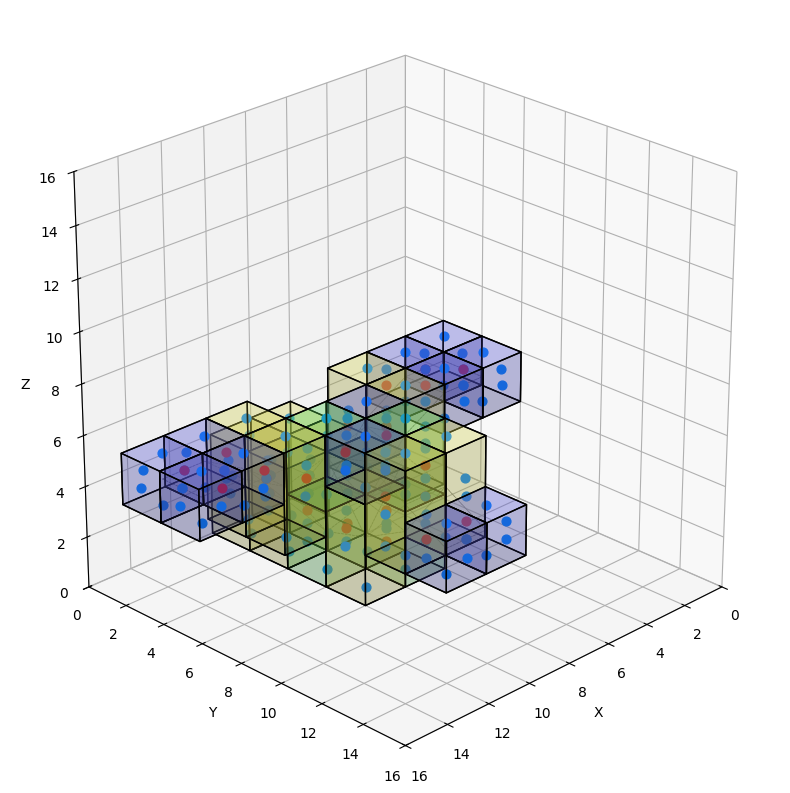

In [56]:
# =================================================
# PIPELINE EXECUTION
# =================================================

voxel_matrix = (voxel_segment_clean > 0).astype(int)
voxel_matrix = np.transpose(voxel_matrix, (0, 2, 1))

DEBUG = False  # toggle for extra prints


# -------------------------------------------------
# STEP 1: VOXEL → BLOCK CONSTRUCTION
# -------------------------------------------------
columns = voxel_to_2x2_columns(voxel_matrix)
assigned_sequences = assign_sequences_with_stagger(columns)
optimized_sequences = reoptimize_sequences(columns, assigned_sequences)

blocks = build_blocks_from_assigned_sequences(columns, optimized_sequences)
grid_size = voxel_matrix.shape[0]


# -------------------------------------------------
# STEP 2: CSP ROTATION OPTIMIZATION
# -------------------------------------------------
blocks = optimize_block_rotations(blocks, grid_size)

if DEBUG:
    print("\n--- Block Rotations (filtered) ---")
    for b in blocks:
        if b.block_id >= 25:
            print(b.block_id, b.position, b.rotation)


# -------------------------------------------------
# STEP 3: GRID + CONNECTIVITY GRAPH
# -------------------------------------------------
grid = build_block_grid(blocks, grid_size)
components = compute_connected_components(blocks, grid, grid_size)


# -------------------------------------------------
# STEP 4: CONNECTIVITY ANALYSIS
# -------------------------------------------------
print("\n================ CONNECTIVITY REPORT ================\n")

report_connections(blocks, grid_size)
report_attachment_connectivity(blocks, grid_size)
report_attachment_degrees(blocks, grid_size)
report_bridge_blocks(blocks, grid_size)


# -------------------------------------------------
# STEP 5: STRUCTURAL SUMMARY
# -------------------------------------------------
largest = len(components[0]) if components else 0
fragmented_blocks = sum(len(c) for c in components[1:])

print("\n================ STRUCTURE SUMMARY ================")
print(f"Main component size: {largest}")
print(f"Disconnected blocks: {fragmented_blocks}")
print(f"Total components: {len(components)}")


# -------------------------------------------------
# STEP 6: COMPONENT GEOMETRY
# -------------------------------------------------
print("\n================ COMPONENT GEOMETRY ================")

for i, comp in enumerate(components):

    comp_blocks = [b for b in blocks if b.block_id in comp]

    xs = [b.position[0] for b in comp_blocks]
    ys = [b.position[1] for b in comp_blocks]
    zs = [b.position[2] for b in comp_blocks]

    centroid = (
        sum(xs) / len(xs),
        sum(ys) / len(ys),
        sum(zs) / len(zs),
    )

    print(f"\nComponent {i+1}")
    print(f"Size: {len(comp)}")
    print(f"Centroid: {centroid}")


# -------------------------------------------------
# STEP 7: VISUALIZATION
# -------------------------------------------------
neighbor_map = build_neighbor_map(blocks, grid_size)

visualize_blocks_by_type(blocks, grid_size)
visualize_blocks_with_faces(blocks, neighbor_map, grid_size)

## Build Instructions

In [57]:
def generate_row_steps(blocks):
    """
    Groups blocks into assembly steps by Y row.
    Each step contains all blocks whose base position shares the same Y coordinate.
    """

    row_map = defaultdict(list)

    for block in blocks:

        # connectors attach slightly later
        if getattr(block, "category", None) == "connector":

            y = block.position[1] + 1

        else:

            _, y, _ = block.position

        row_map[y].append(block)

    # Sort rows for deterministic assembly order
    sorted_rows = sorted(row_map.keys())

    instruction_steps = []

    for row in sorted_rows:
        instruction_steps.append({
            "row": row,
            "blocks": row_map[row]
        })

    return instruction_steps

instruction_steps = generate_row_steps(blocks)

print(f"Generated {len(instruction_steps)} instruction steps.")

Generated 6 instruction steps.


In [58]:
def compute_instruction_faces(blocks, instruction_steps=None, step_idx=None):

    directions = {
        "+X": (1,0,0,"-X"),
        "-X": (-1,0,0,"+X"),
        "+Y": (0,1,0,"-Y"),
        "-Y": (0,-1,0,"+Y"),
        "+Z": (0,0,1,"-Z"),
        "-Z": (0,0,-1,"+Z"),
    }

    grid_size = max(
        max(b.position[d] + b.size[d] for b in blocks)
        for d in range(3)
    ) + 2

    grid = build_block_grid(blocks, grid_size)

    face_states = {}

    for block in blocks:

        x0, y0, z0 = block.position
        dx, dy, dz = block.size

        face_states[block.block_id] = {}

        for face, (dx_off, dy_off, dz_off, opposite_face) in directions.items():

            nx = x0 + (dx_off > 0) * dx + (dx_off < 0) * -1
            ny = y0 + (dy_off > 0) * dy + (dy_off < 0) * -1
            nz = z0 + (dz_off > 0) * dz + (dz_off < 0) * -1

            neighbor_id = None
            state = "hidden"

            if 0 <= nx < grid_size and 0 <= ny < grid_size and 0 <= nz < grid_size:

                nid = grid[nx, ny, nz]

                if nid != -1 and nid != block.block_id:
                    neighbor_id = nid
                    state = "future"  # DEBUG: force visibility

            face_template = np.array(block.faces[face])

            if FaceType.MALE in face_template:
                face_type = "male"
            elif FaceType.FEMALE in face_template:
                face_type = "female"
            else:
                face_type = "none"

            face_states[block.block_id][face] = {
                "state": state,
                "face_type": face_type,
                "neighbor": neighbor_id
            }

    return face_states

In [59]:
def draw_block(ax, block, alpha=1.0, edgecolor='black'):

    x, y, z = block.position
    dx, dy, dz = block.size

    color = get_block_color(block) / 255.0

    # Vertices
    vertices = np.array([
        [x,     y,     z],
        [x+dx,  y,     z],
        [x+dx,  y+dy,  z],
        [x,     y+dy,  z],

        [x,     y,     z+dz],
        [x+dx,  y,     z+dz],
        [x+dx,  y+dy,  z+dz],
        [x,     y+dy,  z+dz]
    ])

    # Faces
    faces = [
        [vertices[j] for j in [0,1,2,3]],
        [vertices[j] for j in [4,5,6,7]],
        [vertices[j] for j in [0,1,5,4]],
        [vertices[j] for j in [2,3,7,6]],
        [vertices[j] for j in [1,2,6,5]],
        [vertices[j] for j in [0,3,7,4]]
    ]

    poly3d = Poly3DCollection(
        faces,
        facecolors=[color],
        edgecolors=edgecolor,
        linewidths=1,
        alpha=alpha
    )

    ax.add_collection3d(poly3d)

In [60]:
def get_face_center(block, face):
    """
    Returns the 3D center point of a block face.
    """

    x, y, z = block.position
    dx, dy, dz = block.size

    centers = {
        "+X": (x + dx,     y + dy/2, z + dz/2),
        "-X": (x,          y + dy/2, z + dz/2),

        "+Y": (x + dx/2,  y + dy,    z + dz/2),
        "-Y": (x + dx/2,  y,         z + dz/2),

        "+Z": (x + dx/2,  y + dy/2, z + dz),
        "-Z": (x + dx/2,  y + dy/2, z),
    }

    return centers[face]

In [61]:
def get_face_normal(face):

    normals = {
        "+X": (1,0,0),
        "-X": (-1,0,0),

        "+Y": (0,1,0),
        "-Y": (0,-1,0),

        "+Z": (0,0,1),
        "-Z": (0,0,-1),
    }

    return normals[face]

In [62]:
def draw_face_marker(
    ax,
    block,
    face,
    face_type,
    state=None
):
    cx, cy, cz = get_face_center(block, face)

    nx, ny, nz = get_face_normal(face)

    offset = 0.15

    cx += nx * offset
    cy += ny * offset
    cz += nz * offset

    if face_type == "male":

        ax.scatter(
            [cx], [cy], [cz],
            color='red',
            s=180,
            edgecolors='k',
            linewidths=0.75,
            alpha=1.0,
            depthshade=False
        )

    elif face_type == "female":

        ax.scatter(
            [cx], [cy], [cz],
            color='dodgerblue',
            s=80,
            edgecolors='k',
            linewidths=0.75,
            alpha=1.0,
            depthshade=False
        )

In [63]:
def count_blocks_in_step(step_blocks):

    counts = {2:0, 3:0, 4:0}

    for block in step_blocks:
        counts[block.size[2]] += 1

    return counts

In [64]:
def visualize_instruction_step(
    blocks,
    instruction_steps,
    step_idx,
    grid_size,
    face_states=None
):
    import matplotlib.pyplot as plt

    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    # -------------------------------------------------
    # STEP SPLIT
    # -------------------------------------------------

    current_blocks = instruction_steps[step_idx]["blocks"]

    reference_blocks = []

    for prev_idx in range(step_idx):
        reference_blocks.extend(
            instruction_steps[prev_idx]["blocks"]
        )

    # -------------------------------------------------
    # DRAW PREVIOUS ROWS (TRANSPARENT)
    # -------------------------------------------------

    for block in reference_blocks:

        x, y, z = block.position
        dx, dy, dz = block.size

        base_color = get_block_color(block) / 255.0

        vertices = np.array([
            [x,     y,     z],
            [x+dx,  y,     z],
            [x+dx,  y+dy,  z],
            [x,     y+dy,  z],

            [x,     y,     z+dz],
            [x+dx,  y,     z+dz],
            [x+dx,  y+dy,  z+dz],
            [x,     y+dy,  z+dz]
        ])

        faces = [
            [vertices[j] for j in [0,1,2,3]],
            [vertices[j] for j in [4,5,6,7]],
            [vertices[j] for j in [0,1,5,4]],
            [vertices[j] for j in [2,3,7,6]],
            [vertices[j] for j in [1,2,6,5]],
            [vertices[j] for j in [0,3,7,4]]
        ]

        poly3d = Poly3DCollection(
            faces,
            facecolors=[base_color],
            edgecolors='gray',
            linewidths=0.5,
            alpha=0.15
        )

        ax.add_collection3d(poly3d)

    # -------------------------------------------------
    # DRAW CURRENT ROW
    # -------------------------------------------------

    for block in current_blocks:
        draw_block(
            ax,
            block,
            alpha=0.45,
            edgecolor='black'
        )

    # -------------------------------------------------
    # COMPUTE FACES
    # -------------------------------------------------

    if face_states is None:
        face_states = compute_instruction_faces(
            blocks,
            instruction_steps,
            step_idx
        )

    # -------------------------------------------------
    # DRAW FACE MARKERS
    # -------------------------------------------------

    for block in current_blocks:

        block_faces = face_states.get(block.block_id, {})

        for face, info in block_faces.items():

            face_type = info["face_type"]

            if face_type == "none":
                continue

            draw_face_marker(
                ax=ax,
                block=block,
                face=face,
                face_type=face_type,
                state=None
            )

    # -------------------------------------------------
    # AXES
    # -------------------------------------------------

    ax.set_xlim(0, grid_size)
    ax.set_ylim(0, grid_size)
    ax.set_zlim(0, grid_size)

    ax.set_box_aspect([1, 1, 1])

    ax.set_title(f"Assembly Step {step_idx + 1}")

    counts = count_blocks_in_step(current_blocks)

    text = (
        f"2x2x2 (Blue): {counts[2]}\n"
        f"2x2x3 (Green): {counts[3]}\n"
        f"2x2x4 (Yellow): {counts[4]}"
    )

    ax.text2D(
        0.02,
        0.95,
        text,
        transform=ax.transAxes,
        fontsize=10,
        bbox=dict(facecolor='white', alpha=0.8)
    )

    ax.view_init(elev=25, azim=45)

    plt.show()

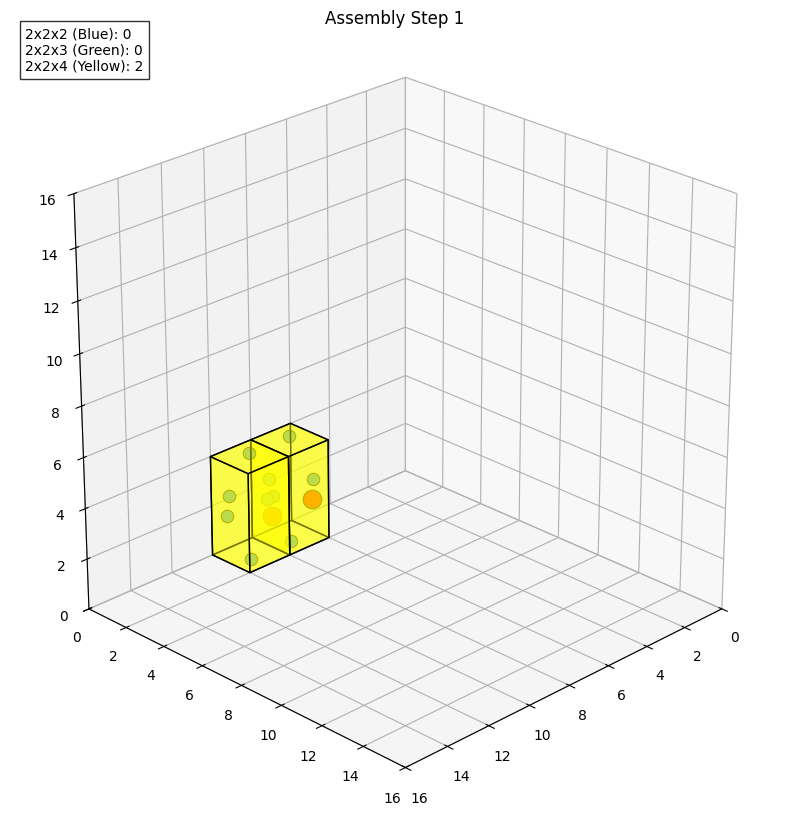

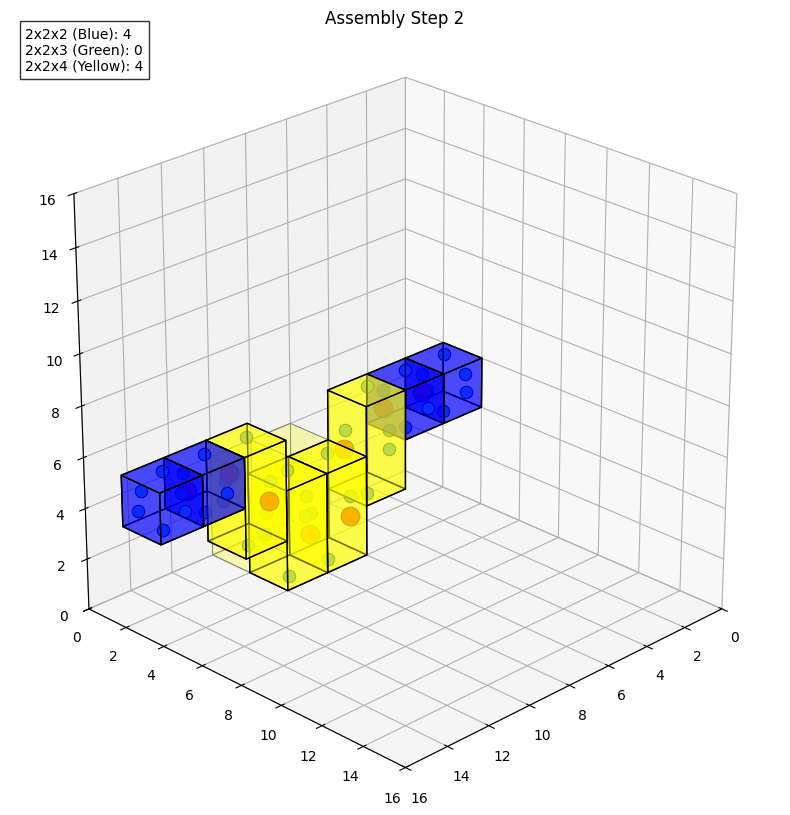

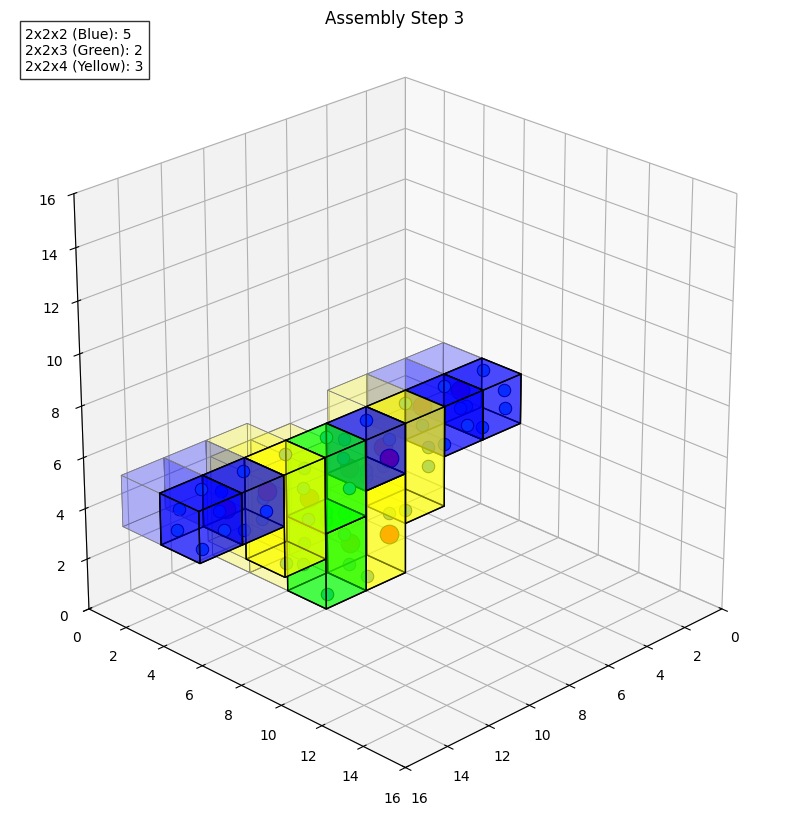

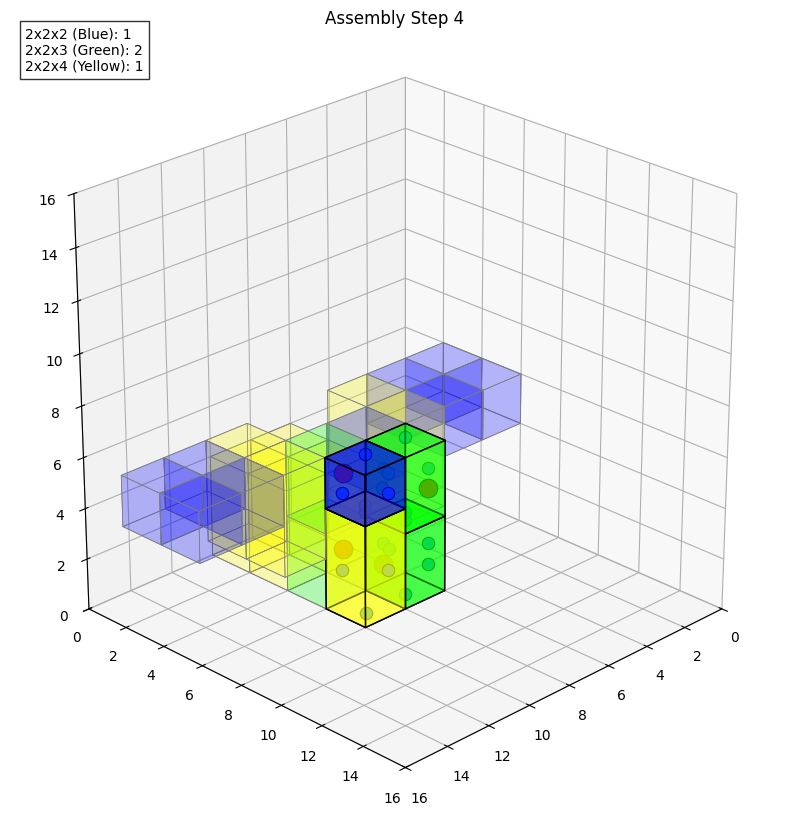

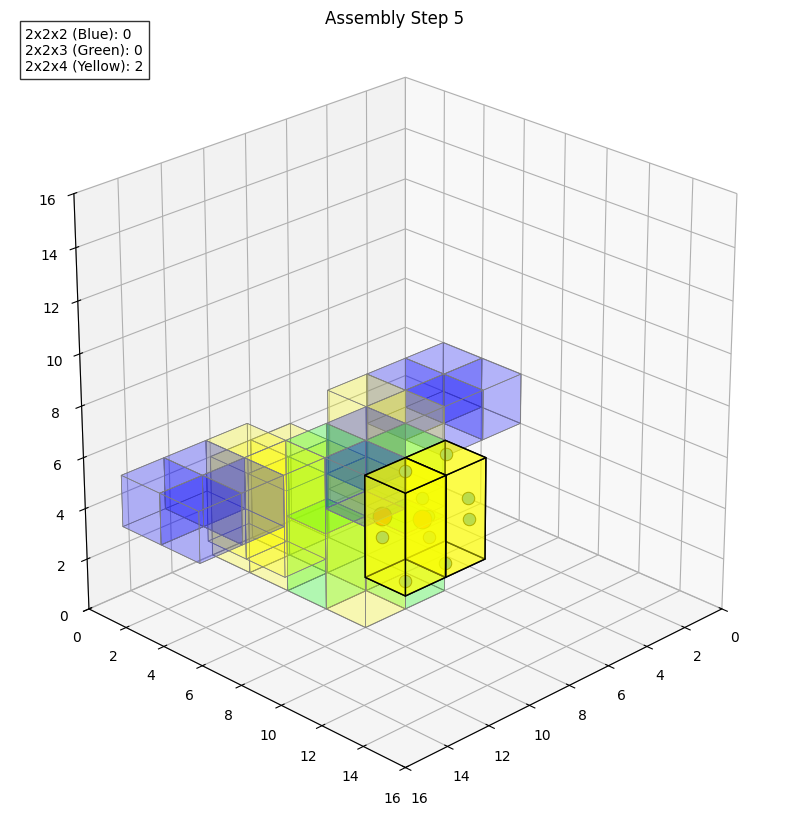

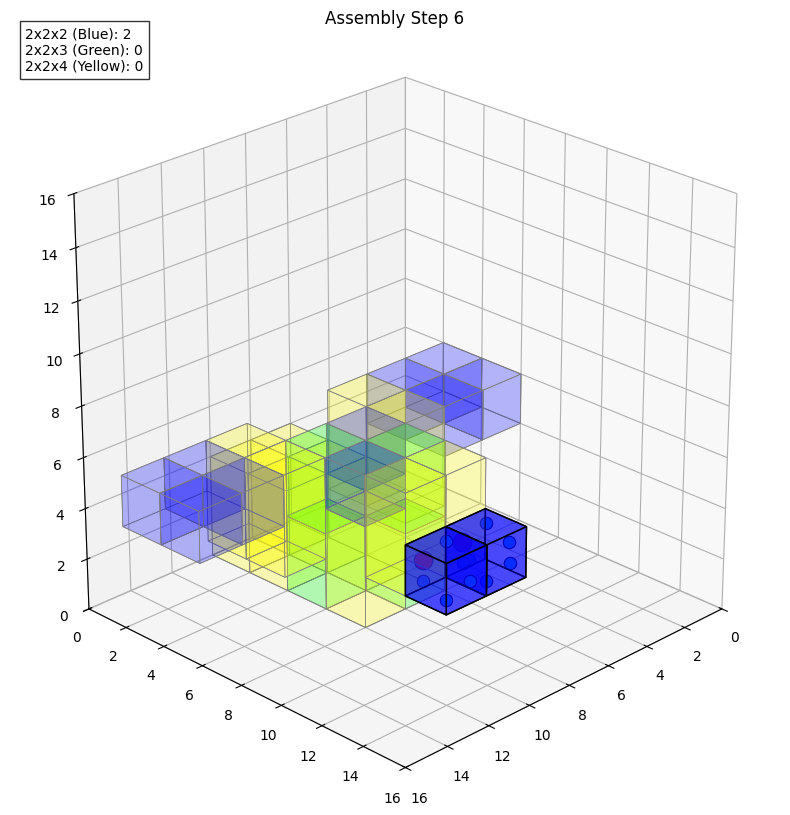

In [65]:
instruction_steps = generate_row_steps(blocks)

for step_idx in range(len(instruction_steps)):

    visualize_instruction_step(
        blocks,
        instruction_steps,
        step_idx,
        grid_size
    )

In [66]:
def visualize_final_object(
    blocks,
    grid_size,
    elev=25,
    azim=45,
    alpha=0.25
):
    """
    Visualize assembled blocks with ONLY male face markers.

    - Opaque blocks
    - Red markers for male faces
    - No female faces
    - No connection lines
    """

    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    # -------------------------------------------------
    # Draw blocks
    # -------------------------------------------------

    for block in blocks:

        x, y, z = block.position
        dx, dy, dz = block.size

        base_color = get_block_color(block) / 255.0

        ax.bar3d(
            x, y, z,
            dx, dy, dz,
            color=base_color,
            edgecolor='k',
            alpha=alpha
        )

    # -------------------------------------------------
    # Draw MALE face markers only
    # -------------------------------------------------

    for block in blocks:

        x, y, z = block.position
        dx, dy, dz = block.size

        if not hasattr(block, "faces"):
            continue

        for face_dir, face_grid in block.faces.items():

            if not any(FaceType.MALE in row for row in face_grid):
                continue

            offset = 0

            if face_dir == '+X':
                fx, fy, fz = (
                    x + dx + offset,
                    y + dy/2,
                    z + dz/2
                )

            elif face_dir == '-X':
                fx, fy, fz = (
                    x - offset,
                    y + dy/2,
                    z + dz/2
                )

            elif face_dir == '+Y':
                fx, fy, fz = (
                    x + dx/2,
                    y + dy + offset,
                    z + dz/2
                )

            elif face_dir == '-Y':
                fx, fy, fz = (
                    x + dx/2,
                    y - offset,
                    z + dz/2
                )

            elif face_dir == '+Z':
                fx, fy, fz = (
                    x + dx/2,
                    y + dy/2,
                    z + dz + offset
                )

            elif face_dir == '-Z':
                fx, fy, fz = (
                    x + dx/2,
                    y + dy/2,
                    z - offset
                )

            ax.scatter(
                fx,
                fy,
                fz,
                color='red',
                edgecolors='black',
                s=150
            )

    # -------------------------------------------------
    # Formatting
    # -------------------------------------------------

    margin = 0.5

    ax.set_xlim(-margin, grid_size + margin)
    ax.set_ylim(-margin, grid_size + margin)
    ax.set_zlim(-margin, grid_size + margin)

    ax.set_box_aspect((1, 1, 1))

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")

    ax.view_init(elev=elev, azim=azim)

    plt.title("Male Face Visualization")

    plt.show()

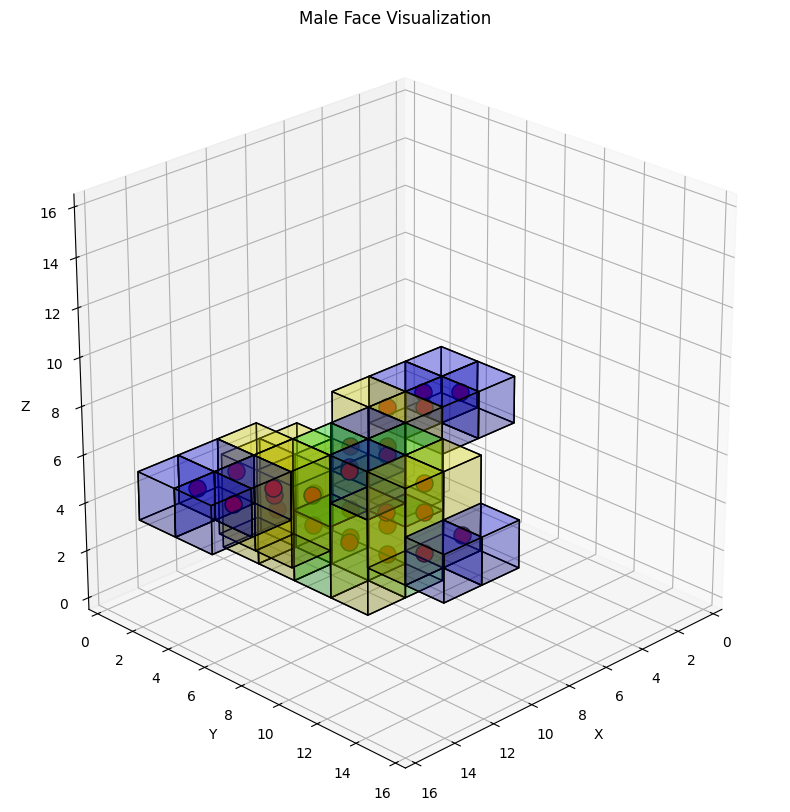

In [67]:
visualize_final_object(
    blocks=blocks,
    grid_size=grid_size,
    elev=25,
    azim=45,
    alpha=0.2
)